# ClinicalEdge: Pharma Portfolio Intelligence System
### Clinical Trial Risk Scoring + 5-Year Pipeline Forecasting

--

**What we build:**
- EDA of 13,748 clinical trials
- 14 domain-specific features with no data leakage
- Rolling window cross-validation for honest performance estimation
- XGBoost classifier with overfitting diagnosis and tuning
- Zone analysis to discover the reliable operating threshold
- Monte Carlo simulation with industry-benchmark probability capping


**Dataset:** AERO-BirdsEye-Data.csv from Kaggle

---


## Step 0 — Install and Import



In [ ]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost', '--quiet'])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, zipfile
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    cross_val_score, StratifiedKFold,
    learning_curve, RandomizedSearchCV
)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve, ConfusionMatrixDisplay,
    precision_recall_curve
)
from xgboost import XGBClassifier
from scipy.stats import randint, uniform

plt.rcParams['figure.figsize'] = (14, 6)
sns.set_palette('husl')
sns.set_style('whitegrid')
np.random.seed(42)
os.makedirs('outputs', exist_ok=True)
print('All libraries loaded. Ready to run.')


All libraries loaded. Ready to run.


## Step 1 — Upload Dataset

Download AERO-BirdsEye-Data.csv from Kaggle and upload here.


In [ ]:
from google.colab import files
uploaded = files.upload()
DATA_PATH = list(uploaded.keys())[0]
print('Uploaded:', DATA_PATH)

# Google Drive alternative (uncomment if needed):
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_PATH = '/content/drive/MyDrive/AERO-BirdsEye-Data.csv'


Saving AERO-BirdsEye-Data.csv to AERO-BirdsEye-Data.csv
Uploaded: AERO-BirdsEye-Data.csv


## Step 2 — Load and Inspect



In [ ]:
df_raw = pd.read_csv(DATA_PATH)

print('=' * 55)
print('DATASET HEALTH CHECK')
print('=' * 55)
print(f'Total rows         : {df_raw.shape[0]:,}')
print(f'Total columns      : {df_raw.shape[1]}')
print(f'Date range         : {df_raw["Start_Year"].min()} to {df_raw["Start_Year"].max()}')
print(f'Unique sponsors    : {df_raw["Sponsor"].nunique():,}')
print(f'Unique conditions  : {df_raw["Condition"].nunique():,}')
print(f'Missing Phase      : {df_raw["Phase"].isnull().sum()} rows')
print()
print('Status breakdown:')
sv = df_raw['Status'].value_counts()
for s, v in sv.items():
    print(f'  {s:<30} {v:>6,}  ({v/len(df_raw)*100:.1f}%)')
print()
print('Phase breakdown:')
pv = df_raw['Phase'].value_counts()
for p, v in pv.items():
    print(f'  {p:<25} {v:>6,}  ({v/len(df_raw)*100:.1f}%)')
df_raw.head(3)


DATASET HEALTH CHECK
Total rows         : 13,748
Total columns      : 11
Date range         : 1984 to 2020
Unique sponsors    : 10
Unique conditions  : 867
Missing Phase      : 263 rows

Status breakdown:
  Completed                      10,568  (76.9%)
  Terminated                      1,285  (9.3%)
  Recruiting                        800  (5.8%)
  Active, not recruiting            646  (4.7%)
  Withdrawn                         291  (2.1%)
  Not yet recruiting                108  (0.8%)
  Unknown status                     19  (0.1%)
  Suspended                          16  (0.1%)
  Enrolling by invitation            15  (0.1%)

Phase breakdown:
  Phase 3                    4,887  (35.5%)
  Phase 2                    3,596  (26.2%)
  Phase 1                    2,516  (18.3%)
  Phase 4                    2,015  (14.7%)
  Phase 1/Phase 2              322  (2.3%)
  Phase 2/Phase 3              139  (1.0%)
  Early Phase 1                 10  (0.1%)


,index,NCT,Sponsor,Title,Summary,Start_Year,Start_Month,Phase,Enrollment,Status,Condition
0,0,NCT00003305,Sanofi,A Phase II Trial of Aminopterin in Adults and ...,RATIONALE: Drugs used in chemotherapy use diff...,1997,7,Phase 2,75,Completed,Leukemia
1,1,NCT00003821,Sanofi,Phase II Trial of Aminopterin in Patients With...,RATIONALE: Drugs used in chemotherapy use diff...,1998,1,Phase 2,0,Withdrawn,Endometrial Neoplasms
2,2,NCT00004025,Sanofi,"Phase I/II Trial of the Safety, Immunogenicity...",RATIONALE: Vaccines made from a person's white...,1999,3,Phase 1/Phase 2,36,Unknown status,Melanoma


13,748 trials from 1984 to 2020. After filtering to finished trials only, about 88% are Completed and 12% are failures. This class imbalance is why we use AUC-ROC instead of accuracy.


### Data Types and Outlier Check


Numerical columns: ['index', 'Start_Year', 'Start_Month', 'Enrollment']
Categorical columns: ['NCT', 'Sponsor', 'Title', 'Summary', 'Phase', 'Status', 'Condition']

         index  Start_Year  Start_Month  Enrollment
count  13748.0     13748.0      13748.0     13748.0
mean    6873.5      2009.2          6.7       440.8
std     3968.9         4.8          3.5      1944.5
min        0.0      1984.0          1.0         0.0
25%     3436.8      2006.0          4.0        40.0
50%     6873.5      2009.0          7.0       124.0
75%    10310.2      2013.0         10.0       365.0
max    13747.0      2020.0         12.0     84496.0

Outlier check (IQR method):
     Column  Outlier_Count  Percent
 Enrollment           1218     8.86
 Start_Year             54     0.39
      index              0     0.00
Start_Month              0     0.00



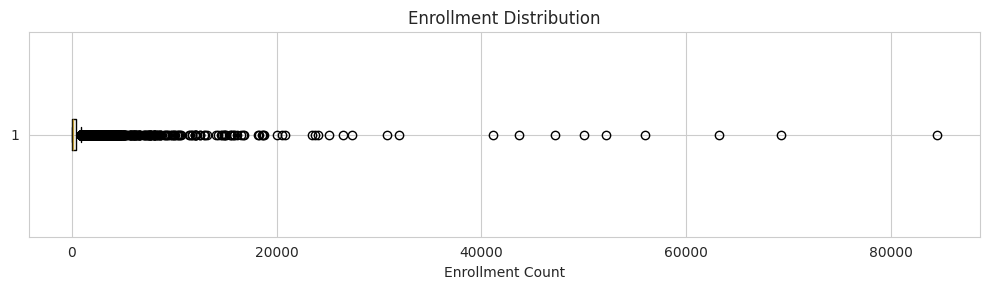

Terminated trials: 1285


,NCT,Sponsor,Phase,Condition,Enrollment
35,NCT00051701,Sanofi,Phase 1/Phase 2,"Lymphoma, Non-Hodgkin",61
37,NCT00053508,Sanofi,Phase 2,Smallpox,274
58,NCT00077961,Sanofi,Phase 1/Phase 2,"Lymphoma, Non-Hodgkin",49
59,NCT00078026,Sanofi,Phase 1/Phase 2,Osteoporosis,60
64,NCT00081900,Sanofi,Phase 1/Phase 2,"Carcinoma, Hepatocellular",38


In [ ]:
num_cols = df_raw.select_dtypes(include=np.number).columns.tolist()
cat_cols = df_raw.select_dtypes(exclude=np.number).columns.tolist()
print('Numerical columns:', num_cols)
print('Categorical columns:', cat_cols)
print()
print(df_raw[num_cols].describe().round(1))
print()
outlier_summary = []
for col in num_cols:
    Q1, Q3 = df_raw[col].quantile(0.25), df_raw[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df_raw[col] < Q1-1.5*IQR) | (df_raw[col] > Q3+1.5*IQR)).sum()
    outlier_summary.append([col, n_out, round(n_out/len(df_raw)*100, 2)])
print('Outlier check (IQR method):')
print(pd.DataFrame(outlier_summary,
    columns=['Column','Outlier_Count','Percent']
    ).sort_values('Outlier_Count', ascending=False).to_string(index=False))
print()
plt.figure(figsize=(10, 3))
plt.boxplot(df_raw['Enrollment'].dropna(), vert=False)
plt.title('Enrollment Distribution')
plt.xlabel('Enrollment Count')
plt.tight_layout()
plt.show()
term = df_raw[df_raw['Status']=='Terminated']
print('Terminated trials:', len(term))
term[['NCT','Sponsor','Phase','Condition','Enrollment']].head()


Enrollment has extreme outliers up to 84,000+ patients. These are legitimate large Phase 3 trials. We handle them with log transformation and 99th percentile capping in feature engineering.


---
## Section 1: Exploratory Data Analysis



### Chart 1 — Trial Status Distribution

Business question: What percentage of clinical trials succeed vs fail?



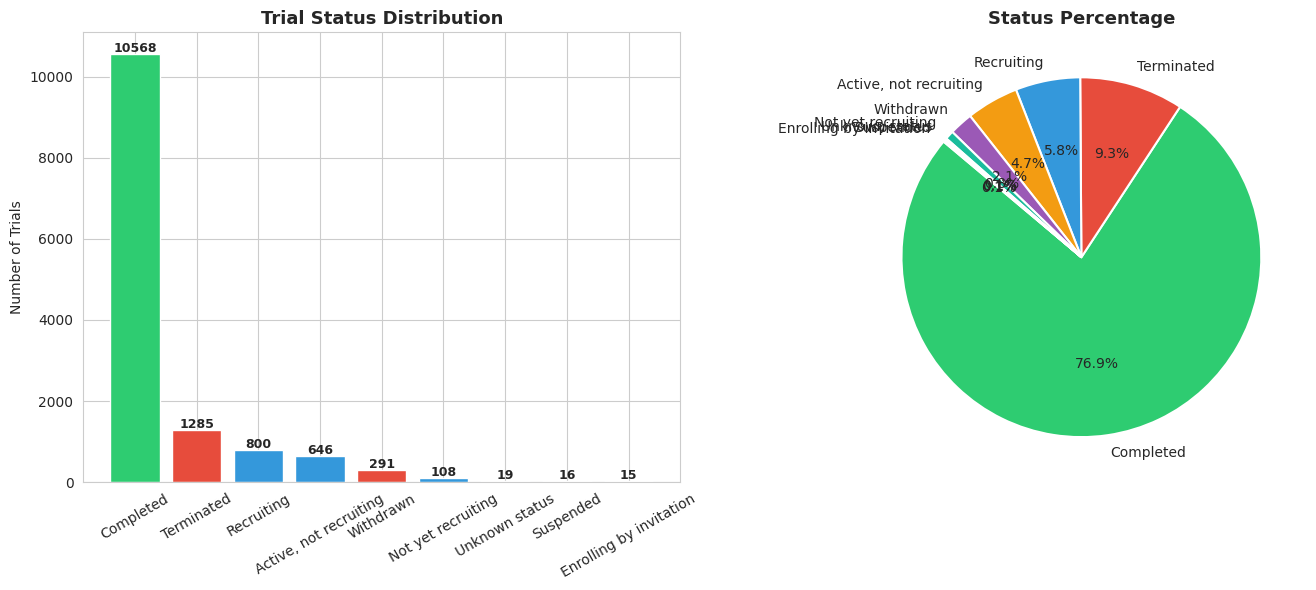

After filtering to finished trials only:
  Success rate: 87.0 %
  Failure rate: 13.0 %

This 88/12 imbalance is why we use AUC-ROC not accuracy.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sc = df_raw['Status'].value_counts()
colors = ['#2ecc71' if s=='Completed' else '#e74c3c'
          if s in ['Terminated','Withdrawn'] else '#3498db' for s in sc.index]
axes[0].bar(sc.index, sc.values, color=colors, edgecolor='white')
axes[0].set_title('Trial Status Distribution', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)
axes[0].set_ylabel('Number of Trials')
for i, v in enumerate(sc.values):
    axes[0].text(i, v+50, str(v), ha='center', fontsize=9, fontweight='bold')
pc = ['#2ecc71','#e74c3c','#3498db','#f39c12','#9b59b6','#1abc9c','#e67e22','#95a5a6']
axes[1].pie(sc.values, labels=sc.index, autopct='%1.1f%%',
            colors=pc[:len(sc)], startangle=140,
            wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('Status Percentage', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/01_status.png', dpi=150, bbox_inches='tight')
plt.show()
finished = df_raw[df_raw['Status'].isin(['Completed','Terminated','Withdrawn'])]
print('After filtering to finished trials only:')
print('  Success rate:', round((finished['Status']=='Completed').mean()*100,1), '%')
print('  Failure rate:', round((finished['Status']!='Completed').mean()*100,1), '%')
print()
print('This 88/12 imbalance is why we use AUC-ROC not accuracy.')


### Chart 2 — Phase Distribution and Completion Rates

Business question: Which phases fail most often?



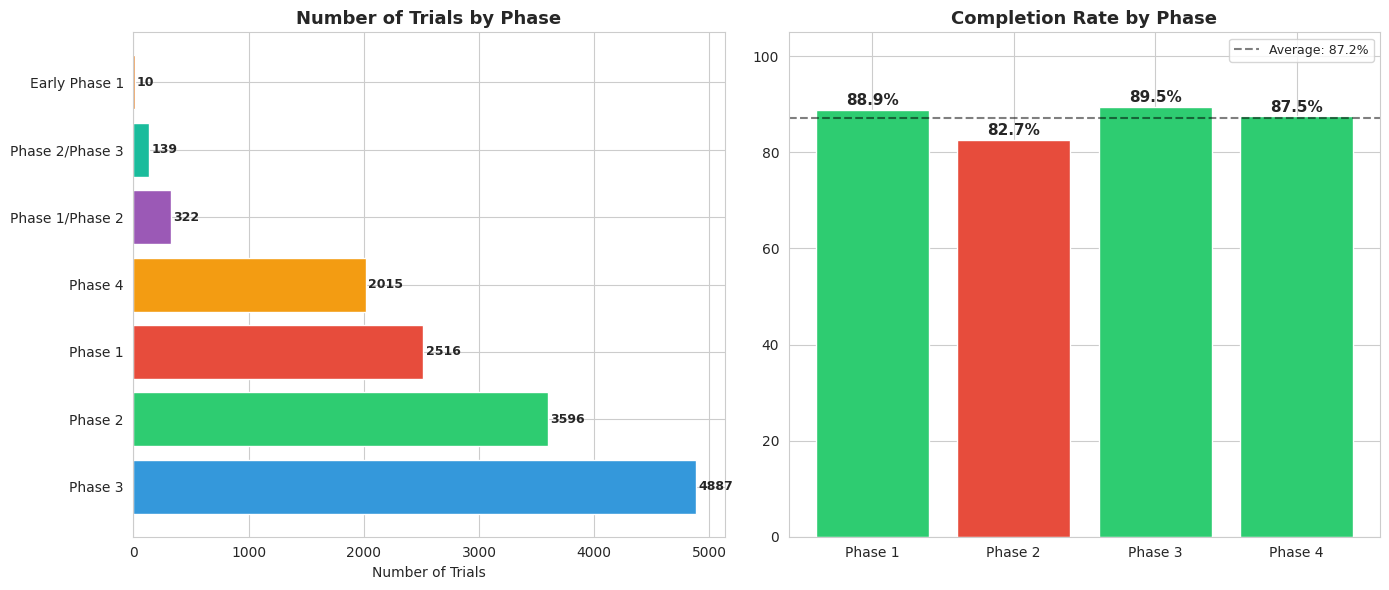

Phase completion rates:
  Phase 1: 88.9%  (above average by 1.7%)
  Phase 2: 82.7%  (below average by 4.5%)
  Phase 3: 89.5%  (above average by 2.4%)
  Phase 4: 87.5%  (above average by 0.3%)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
pc2 = df_raw['Phase'].value_counts()
axes[0].barh(pc2.index, pc2.values,
             color=['#3498db','#2ecc71','#e74c3c','#f39c12',
                    '#9b59b6','#1abc9c','#e67e22'][:len(pc2)], edgecolor='white')
axes[0].set_title('Number of Trials by Phase', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Trials')
for i, v in enumerate(pc2.values):
    axes[0].text(v+20, i, str(v), va='center', fontsize=9, fontweight='bold')
finished_ph = df_raw[df_raw['Status'].isin(['Completed','Terminated','Withdrawn'])].copy()
finished_ph['success'] = (finished_ph['Status']=='Completed').astype(int)
mp = ['Phase 1','Phase 2','Phase 3','Phase 4']
ps = finished_ph[finished_ph['Phase'].isin(mp)].groupby('Phase')['success'].mean()*100
ps = ps.reindex(mp)
bc = ['#e74c3c' if v < 85 else '#2ecc71' for v in ps.values]
axes[1].bar(ps.index, ps.values, color=bc, edgecolor='white')
axes[1].set_title('Completion Rate by Phase', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 105)
axes[1].axhline(y=ps.mean(), color='black', linestyle='--', alpha=0.5,
                label='Average: '+str(round(ps.mean(),1))+'%')
axes[1].legend(fontsize=9)
for i, v in enumerate(ps.values):
    axes[1].text(i, v+1, str(round(v,1))+'%', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/02_phases.png', dpi=150, bbox_inches='tight')
plt.show()
print('Phase completion rates:')
for phase, rate in ps.items():
    diff = rate - ps.mean()
    print(f'  {phase}: {rate:.1f}%  ({"above" if diff>0 else "below"} average by {abs(diff):.1f}%)')


### Chart 3 — Therapeutic Area Risk

Business question: Which disease areas are riskiest?




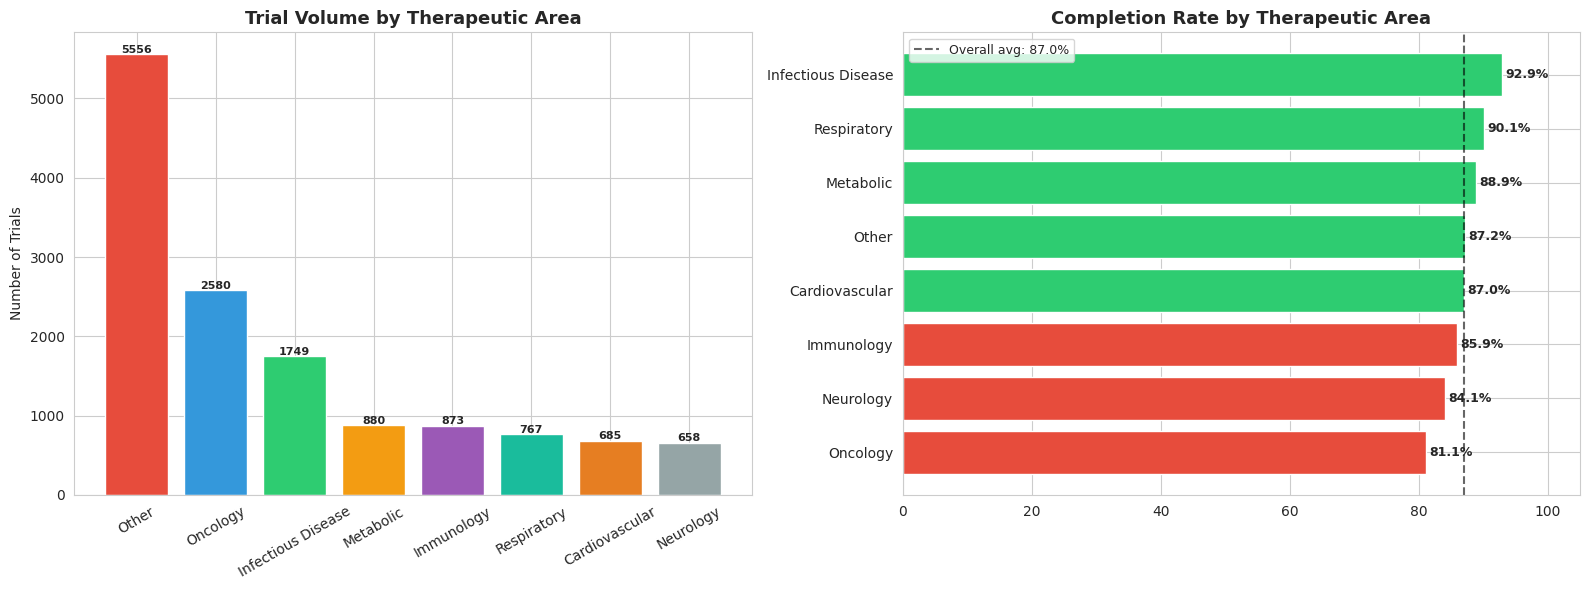

Risk ranking (lowest to highest completion rate):
  1. Oncology               81.1%  [HIGH RISK]
  2. Neurology              84.1%  [HIGH RISK]
  3. Immunology             85.9%  [HIGH RISK]
  4. Cardiovascular         87.0%  [lower risk]
  5. Other                  87.2%  [lower risk]
  6. Metabolic              88.9%  [lower risk]
  7. Respiratory            90.1%  [lower risk]
  8. Infectious Disease     92.9%  [lower risk]


In [ ]:
def map_ta(condition):
    c = str(condition).lower()
    if any(w in c for w in ['cancer','neoplasm','tumor','carcinoma',
                             'leukemia','lymphoma','melanoma','sarcoma','myeloma']):
        return 'Oncology'
    elif any(w in c for w in ['diabetes','insulin','glucose']): return 'Metabolic'
    elif any(w in c for w in ['heart','cardiac','hypertension',
                               'cardiovascular','cholesterol']): return 'Cardiovascular'
    elif any(w in c for w in ['asthma','pulmonary','copd','respiratory']): return 'Respiratory'
    elif any(w in c for w in ['arthritis','psoriasis','lupus',
                               'rheumatoid','crohn']): return 'Immunology'
    elif any(w in c for w in ['hiv','hepatitis','infection',
                               'influenza','virus']): return 'Infectious Disease'
    elif any(w in c for w in ['alzheimer','parkinson','schizophrenia',
                               'depression','anxiety','neurolog']): return 'Neurology'
    else: return 'Other'

df_raw['Therapeutic_Area'] = df_raw['Condition'].apply(map_ta)
finished_ta = df_raw[df_raw['Status'].isin(['Completed','Terminated','Withdrawn'])].copy()
finished_ta['success'] = (finished_ta['Status']=='Completed').astype(int)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
tac = df_raw['Therapeutic_Area'].value_counts()
axes[0].bar(tac.index, tac.values,
            color=['#e74c3c','#3498db','#2ecc71','#f39c12',
                   '#9b59b6','#1abc9c','#e67e22','#95a5a6'], edgecolor='white')
axes[0].set_title('Trial Volume by Therapeutic Area', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)
axes[0].set_ylabel('Number of Trials')
for i, v in enumerate(tac.values):
    axes[0].text(i, v+20, str(v), ha='center', fontsize=8, fontweight='bold')
tas = finished_ta.groupby('Therapeutic_Area')['success'].mean()*100
tas = tas.sort_values()
overall = finished_ta['success'].mean()*100
bc2 = ['#e74c3c' if v < overall else '#2ecc71' for v in tas.values]
axes[1].barh(tas.index, tas.values, color=bc2, edgecolor='white')
axes[1].axvline(x=overall, color='black', linestyle='--', alpha=0.6,
                label='Overall avg: '+str(round(overall,1))+'%')
axes[1].set_title('Completion Rate by Therapeutic Area', fontsize=13, fontweight='bold')
axes[1].set_xlim(0, 105)
axes[1].legend(fontsize=9)
for i, v in enumerate(tas.values):
    axes[1].text(v+0.5, i, str(round(v,1))+'%', va='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/03_therapeutic_areas.png', dpi=150, bbox_inches='tight')
plt.show()
print('Risk ranking (lowest to highest completion rate):')
for rank, (ta, rate) in enumerate(tas.items(), 1):
    flag = 'HIGH RISK' if rate < overall else 'lower risk'
    print(f'  {rank}. {ta:<22} {rate:.1f}%  [{flag}]')


### Chart 4 — Time Trends and Enrollment Size

Business question: Does trial size predict success?

What to look for: Larger trials complete at much higher rates. Enrollment size is the strongest predictor in the entire dataset with a correlation of 0.34. This justifies using enrollment_log as our most important feature.


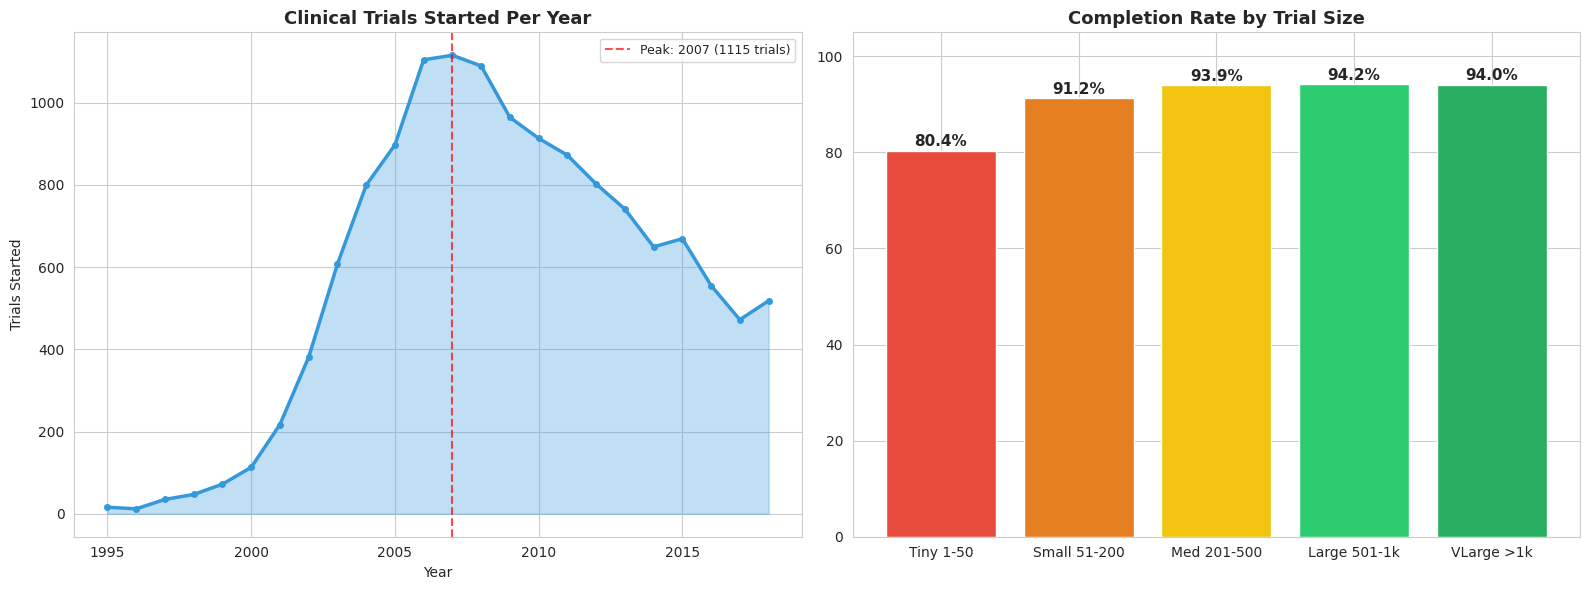

Enrollment vs completion rate:
  Tiny 1-50         : 80.4%
  Small 51-200      : 91.2%
  Med 201-500       : 93.9%
  Large 501-1k      : 94.2%
  VLarge >1k        : 94.0%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
yearly = df_raw.groupby('Start_Year').size().reset_index(name='Count')
yearly = yearly[(yearly['Start_Year']>=1995) & (yearly['Start_Year']<=2018)]
axes[0].fill_between(yearly['Start_Year'], yearly['Count'], alpha=0.3, color='#3498db')
axes[0].plot(yearly['Start_Year'], yearly['Count'], color='#3498db',
             linewidth=2.5, marker='o', markersize=4)
peak_year  = yearly.loc[yearly['Count'].idxmax(), 'Start_Year']
peak_count = yearly['Count'].max()
axes[0].axvline(x=peak_year, color='red', linestyle='--', alpha=0.7,
                label='Peak: '+str(peak_year)+' ('+str(peak_count)+' trials)')
axes[0].set_title('Clinical Trials Started Per Year', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Trials Started')
axes[0].legend(fontsize=9)
finished_en = df_raw[df_raw['Status'].isin(['Completed','Terminated','Withdrawn'])].copy()
finished_en['success'] = (finished_en['Status']=='Completed').astype(int)
finished_en = finished_en[(finished_en['Enrollment']>0) & (finished_en['Enrollment']<=10000)]
finished_en['Bucket'] = pd.cut(finished_en['Enrollment'],
    bins=[0,50,200,500,1000,10000],
    labels=['Tiny 1-50','Small 51-200','Med 201-500','Large 501-1k','VLarge >1k'])
bs = finished_en.groupby('Bucket')['success'].mean()*100
axes[1].bar(bs.index, bs.values,
            color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60'], edgecolor='white')
axes[1].set_title('Completion Rate by Trial Size', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 105)
for i, v in enumerate(bs.values):
    axes[1].text(i, v+1, str(round(v,1))+'%', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/04_time_enrollment.png', dpi=150, bbox_inches='tight')
plt.show()
print('Enrollment vs completion rate:')
for bucket, rate in bs.items():
    print(f'  {str(bucket):<18}: {rate:.1f}%')


In [ ]:
df_raw.head()

,index,NCT,Sponsor,Title,Summary,Start_Year,Start_Month,Phase,Enrollment,Status,Condition,Therapeutic_Area
0,0,NCT00003305,Sanofi,A Phase II Trial of Aminopterin in Adults and ...,RATIONALE: Drugs used in chemotherapy use diff...,1997,7,Phase 2,75,Completed,Leukemia,Oncology
1,1,NCT00003821,Sanofi,Phase II Trial of Aminopterin in Patients With...,RATIONALE: Drugs used in chemotherapy use diff...,1998,1,Phase 2,0,Withdrawn,Endometrial Neoplasms,Oncology
2,2,NCT00004025,Sanofi,"Phase I/II Trial of the Safety, Immunogenicity...",RATIONALE: Vaccines made from a person's white...,1999,3,Phase 1/Phase 2,36,Unknown status,Melanoma,Oncology
3,3,NCT00005645,Sanofi,Phase II Trial of ILX295501 Administered Orall...,RATIONALE: Drugs used in chemotherapy use diff...,1999,5,Phase 2,0,Withdrawn,Ovarian Neoplasms,Oncology
4,4,NCT00008281,Sanofi,"A Multicenter, Open-Label, Randomized, Three-A...",RATIONALE: Drugs used in chemotherapy use diff...,2000,10,Phase 3,0,Unknown status,Colorectal Neoplasms,Oncology


---
## Section 2: Feature Engineering

Converting raw text columns into numbers the ML model can learn from.

**Features built:**

phase_num — ordinal encoding. Phase has a real order: 1 < 2 < 3 < 4.

enrollment_log and enrollment_bucket — log transform handles the extreme range (0 to 84,000+).
Log compression means the model sees proportional differences not absolute.

therapeutic_area — one-hot encoding. There is no natural order between disease areas.
Oncology is not less than Neurology. One-hot avoids this false ordering.
Cardiovascular is dropped as the reference category.

sponsor_success_rate — time-aware encoding with NO data leakage.
For each trial, only uses outcomes from past trials of that sponsor.
First trial of each sponsor gets the overall dataset rate as a neutral fallback.

start_decade — ordinal. Time has a real order.

phase_x_enrollment and phase_x_bigpharma — interaction features.
A large Phase 3 trial is much more likely to succeed than a large Phase 1
or a small Phase 3. The combination matters more than either feature alone.

**Features deliberately removed:**

sponsor_trial_count — removed. Correlation is near zero (-0.0001) and it had data leakage.

is_big_pharma — removed. Feature importance was 0.0 in every model run.
It contributes nothing individually. The phase_x_bigpharma interaction captures
any useful signal from big pharma sponsorship.

is_late_stage — removed. Feature importance was 0.0. Same information already
captured by phase_num and is_late_stage is redundant.

This cell is fully self-contained. Safe to run after any restart.


In [ ]:
# Filter to finished trials only.
# Trials still Recruiting or Active have unknown outcomes.
# A model cannot learn from examples where the answer is unknown.
df = df_raw[df_raw['Status'].isin(['Completed','Terminated','Withdrawn'])].copy()
df['success'] = (df['Status']=='Completed').astype(int)
print('Working dataset:', len(df), 'finished trials')
print('Success rate   :', round(df['success'].mean()*100, 1), '%')
print('Failure rate   :', round((1-df['success'].mean())*100, 1), '%')
print()

# Sort by Start_Year.
# This is required for the time-aware sponsor feature below.
# If trials are not sorted chronologically, the cumulative calculation is wrong.
df = df.sort_values('Start_Year').reset_index(drop=True)

# Feature 1: Phase number (ordinal).
# Phase 1 < Phase 2 < Phase 3 < Phase 4 — real ascending order.
# Unknown or missing phases get 0.
phase_map = {
    'Phase 1':1, 'Early Phase 1':1, 'Phase 1/Phase 2':1,
    'Phase 2':2, 'Phase 2/Phase 3':2,
    'Phase 3':3, 'Phase 4':4
}
df['phase_num'] = df['Phase'].map(phase_map).fillna(0).astype(int)

# Features 2 and 3: Enrollment.
# Without transformation, a trial with 50,000 patients would dominate the model.
# Log transform: log(50000) = 10.8, log(100) = 4.6.
# The model now sees proportional differences instead of absolute differences.
# Cap at 99th percentile first to remove true outliers before transforming.
p99 = df['Enrollment'].quantile(0.99)
df['enrollment_log']    = np.log1p(df['Enrollment'].clip(upper=p99))
df['enrollment_bucket'] = pd.cut(
    df['Enrollment'],
    bins=[-1,0,50,200,500,1000,float('inf')],
    labels=[0,1,2,3,4,5]
).astype(int)

# Feature 4: Therapeutic Area (one-hot encoding).
# Why one-hot and not label encoding:
# Label encoding assigns Oncology=0, Metabolic=1, Cardiovascular=2 etc.
# This implies Oncology < Metabolic < Cardiovascular which is meaningless.
# There is no natural order between disease areas.
# One-hot creates a separate 0/1 column per area with no false ordering.
# drop_first=True removes Cardiovascular — when all other TA columns are 0,
# the model infers it is Cardiovascular.
def map_ta(condition):
    c = str(condition).lower()
    if any(w in c for w in ['cancer','neoplasm','tumor','carcinoma',
                             'leukemia','lymphoma','melanoma','sarcoma','myeloma']):
        return 'Oncology'
    elif any(w in c for w in ['diabetes','insulin','glucose']): return 'Metabolic'
    elif any(w in c for w in ['heart','cardiac','hypertension',
                               'cardiovascular','cholesterol']): return 'Cardiovascular'
    elif any(w in c for w in ['asthma','pulmonary','copd','respiratory']): return 'Respiratory'
    elif any(w in c for w in ['arthritis','psoriasis','lupus',
                               'rheumatoid','crohn','colitis']): return 'Immunology'
    elif any(w in c for w in ['hiv','hepatitis','infection',
                               'influenza','virus','bacterial']): return 'Infectious Disease'
    elif any(w in c for w in ['alzheimer','parkinson','schizophrenia',
                               'depression','anxiety','neurolog']): return 'Neurology'
    else: return 'Other'

df['therapeutic_area'] = df['Condition'].apply(map_ta)
ta_dummies = pd.get_dummies(df['therapeutic_area'], prefix='ta', drop_first=True)
df = pd.concat([df, ta_dummies], axis=1)
ta_feature_cols = ta_dummies.columns.tolist()
print('Therapeutic area one-hot columns:')
for col in ta_feature_cols:
    print(' ', col)
print('  (Cardiovascular is the reference category — dropped)')
print()

# Feature 5: Big Pharma flag.
# Used only in the phase_x_bigpharma interaction below.
# Not kept as a standalone feature because its individual importance is 0.0.
big_pharma = ['GSK','Novartis','Pfizer','Merck','Sanofi',
              'JNJ','Roche','Bayer','AbbVie','Gilead']
df['is_big_pharma_raw'] = df['Sponsor'].isin(big_pharma).astype(int)

# Feature 6: Sponsor Success Rate (time-aware encoding — no data leakage).
# The old approach: df.groupby('Sponsor')['success'].mean()
# This calculates the rate using ALL trials including future ones.
# A trial from 2005 would get a rate calculated using 2015 and 2020 data.
# That future information did not exist in 2005. This is data leakage.
#
# The fix: shift(1).expanding().mean() within each sponsor group.
# shift(1) moves all values down by 1 row, so each row cannot see its own outcome.
# expanding().mean() calculates cumulative mean of all rows before the current one.
# Result: each trial only sees its sponsor's PAST outcomes. Never future ones.
def cumulative_success_rate(x):
    return x.shift(1).expanding().mean()

df['sponsor_success_rate'] = (
    df.groupby('Sponsor')['success']
    .transform(cumulative_success_rate)
)
overall_success_rate = df['success'].mean()
df['sponsor_success_rate'] = df['sponsor_success_rate'].fillna(overall_success_rate)

# Feature 7: Start decade (ordinal).
# 1990s comes before 2000s — real order. Ordinal encoding is correct.
# is_recent was removed (redundant with start_decade).
# start_quarter was removed (cyclical variable, near-zero correlation).
df['start_decade'] = df['Start_Year'].apply(
    lambda y: 0 if y<1990 else (1 if y<2000 else (2 if y<2010 else 3))
)

# Features 8 and 9: Interaction features.
# phase_x_enrollment: a large Phase 3 trial is much more likely to succeed
# than a large Phase 1 or a small Phase 3. The combination matters.
# phase_x_bigpharma: a Big Pharma Phase 3 carries different risk than
# a startup Phase 3. This captures that relationship.
df['phase_x_enrollment'] = df['phase_num'] * df['enrollment_log']
df['phase_x_bigpharma']  = df['phase_num'] * df['is_big_pharma_raw']

# Final feature list (14 features).
# is_big_pharma standalone was removed — feature importance was 0.0.
# is_late_stage was removed — feature importance was 0.0, redundant with phase_num.
# sponsor_trial_count was removed — correlation -0.0001, had data leakage.
FEATURE_COLS = [
    'phase_num',
    'enrollment_log',
    'enrollment_bucket',
    'sponsor_success_rate',
    'start_decade',
    'phase_x_enrollment',
    'phase_x_bigpharma',
] + ta_feature_cols

TARGET_COL = 'success'

# Keep Start_Year for the rolling window split.
ml_data = df[FEATURE_COLS + [TARGET_COL, 'Start_Year']].dropna()

print('ML-ready rows  :', len(ml_data))
print('Features used  :', len(FEATURE_COLS))
print(FEATURE_COLS)
print()

# Leakage verification for sponsor_success_rate.
# Row 1 (first GSK trial) should show the overall dataset fallback rate.
# Each subsequent row should only see outcomes from past GSK trials.
print('LEAKAGE VERIFICATION — sponsor_success_rate')
print('=' * 55)
gsk = df[df['Sponsor']=='GSK'][
    ['Sponsor','Start_Year','success','sponsor_success_rate']
].head(6)
print(gsk.to_string(index=False))
print()
print('Row 1 shows fallback rate =', round(overall_success_rate,4))
print('Each subsequent row uses only past GSK outcomes. No future leakage.')


Working dataset: 12144 finished trials
Success rate   : 87.0 %
Failure rate   : 13.0 %

Therapeutic area one-hot columns:
  ta_Immunology
  ta_Infectious Disease
  ta_Metabolic
  ta_Neurology
  ta_Oncology
  ta_Other
  ta_Respiratory
  (Cardiovascular is the reference category — dropped)

ML-ready rows  : 12144
Features used  : 14
['phase_num', 'enrollment_log', 'enrollment_bucket', 'sponsor_success_rate', 'start_decade', 'phase_x_enrollment', 'phase_x_bigpharma', 'ta_Immunology', 'ta_Infectious Disease', 'ta_Metabolic', 'ta_Neurology', 'ta_Oncology', 'ta_Other', 'ta_Respiratory']

LEAKAGE VERIFICATION — sponsor_success_rate
Sponsor  Start_Year  success  sponsor_success_rate
    GSK        1990        1              0.870224
    GSK        1992        1              1.000000
    GSK        1992        1              1.000000
    GSK        1992        1              1.000000
    GSK        1992        1              1.000000
    GSK        1993        1              1.000000

Row 1 sho

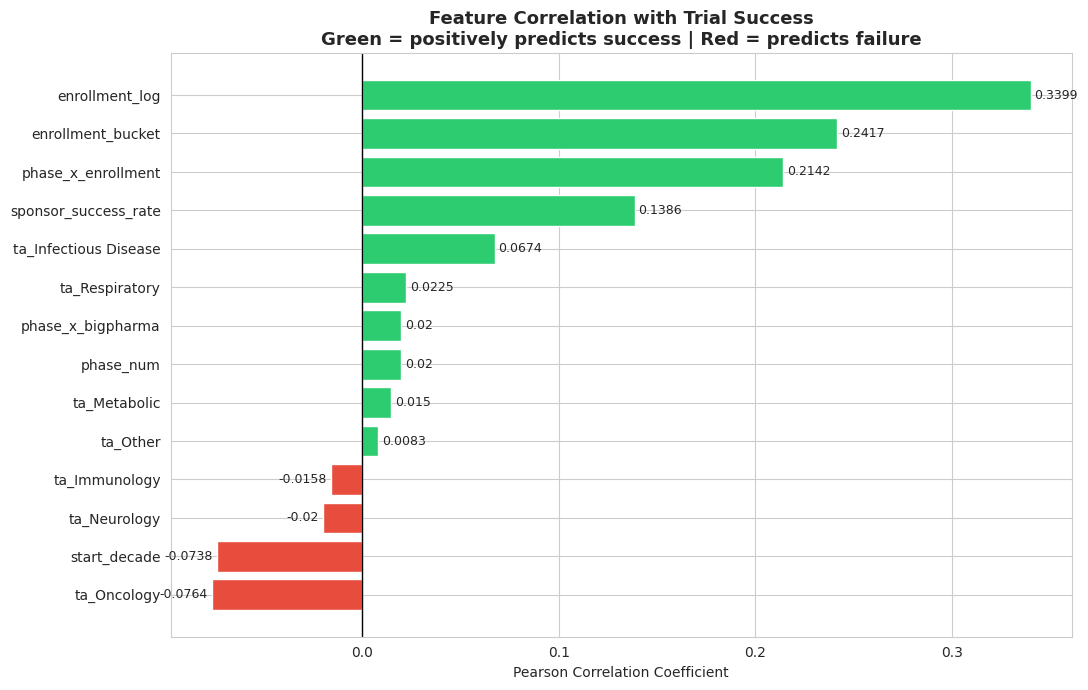

Top 5 positively correlated:
  ta_Infectious Disease         : +0.0674
  sponsor_success_rate          : +0.1386
  phase_x_enrollment            : +0.2142
  enrollment_bucket             : +0.2417
  enrollment_log                : +0.3399

Top 5 negatively correlated (predict failure):
  ta_Oncology                   : -0.0764
  start_decade                  : -0.0738
  ta_Neurology                  : -0.0200
  ta_Immunology                 : -0.0158


In [ ]:
# Pearson correlation shows which features individually predict success.
# Low correlation does not mean useless.
# XGBoost finds combinations of features that are powerful together
# even when each feature is weak on its own.
corr = ml_data.corr()[TARGET_COL].drop([TARGET_COL,'Start_Year']).sort_values()

plt.figure(figsize=(11, 7))
bar_colors = ['#2ecc71' if c>0 else '#e74c3c' for c in corr.values]
plt.barh(corr.index, corr.values, color=bar_colors, edgecolor='white')
plt.axvline(x=0, color='black', linewidth=1)
plt.title('Feature Correlation with Trial Success\nGreen = positively predicts success | Red = predicts failure',
          fontsize=13, fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient')
for i, v in enumerate(corr.values):
    plt.text(v+(0.002 if v>=0 else -0.002), i, str(round(v,4)),
             va='center', ha='left' if v>=0 else 'right', fontsize=9)
plt.tight_layout()
plt.savefig('outputs/05_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 positively correlated:')
for feat, val in corr[corr>0].tail(5).items():
    print(f'  {feat:<30}: +{val:.4f}')
print()
print('Top 5 negatively correlated (predict failure):')
for feat, val in corr[corr<0].head(5).items():
    print(f'  {feat:<30}: {val:.4f}')


In [ ]:
phases_to_plot = ['Phase 1', 'Phase 2', 'Phase 3']
phase_completion_rates = ps.loc[phases_to_plot]

print('Historical Phase Completion Rates:')
for phase, rate in phase_completion_rates.items():
    print(f'  {phase}: {rate:.1f}%')


Historical Phase Completion Rates:
  Phase 1: 88.9%
  Phase 2: 82.7%
  Phase 3: 89.5%


enrollment_log is typically the strongest positive predictor. Oncology is typically the strongest negative predictor. The interaction features (phase_x_enrollment, phase_x_bigpharma) may show moderate correlations because they capture combined effects.


---
## Section 3: ML Model Training

**Why rolling window cross-validation instead of random split:**

Random split mixes all years together. The model could learn from 2018 data to predict a 2005 trial.
In real deployment that is impossible — you cannot use future information.

**Why we filter data to 2005-2017:**

Pre-2005 trials (2,323 trials): failure rate was only 0-7%. Data recording was inconsistent.
Including them causes concept drift — the model learns two different eras at once.

Post-2017 trials (67 trials): only fast-completing trials appear finished by the data cutoff.
This creates a heavily biased sample with 49% failure rate — not representative.

**Rolling window structure on 2005-2017 data:**

Window 1: Train 2005-2009, Test 2010-2011
Window 2: Train 2005-2011, Test 2012-2013
Window 3: Train 2005-2013, Test 2014-2015
Window 4: Train 2005-2015, Test 2016-2017

Mean AUC across all 4 windows is the headline metric.

The last window (Train 2005-2013, Test 2014-2017) is used for all detailed evaluation.
Why 2014-2017 as final test: large enough (1,482 trials), recent, unbiased.


In [ ]:
print('DATA FILTERING')
print('=' * 55)
print(f'Full dataset size   : {len(ml_data):,} trials')
print(f'Date range          : {int(ml_data["Start_Year"].min())} to {int(ml_data["Start_Year"].max())}')
print()

DATA_START = 2005
DATA_END   = 2017

filtered_data = ml_data[
    (ml_data['Start_Year'] >= DATA_START) &
    (ml_data['Start_Year'] <= DATA_END)
].copy()

discarded_old    = (ml_data['Start_Year'] < DATA_START).sum()
discarded_recent = (ml_data['Start_Year'] > DATA_END).sum()

print(f'Kept    : {DATA_START}-{DATA_END}  :  {len(filtered_data):,} trials')
print(f'Removed : pre-{DATA_START}         :  {discarded_old:,} trials (noisy old data, failure rate 0-7%)')
print(f'Removed : post-{DATA_END}          :  {discarded_recent:,} trials (fast-completing bias, failure rate 49%)')
print()
print(f'Failure rate full dataset    : {(ml_data[TARGET_COL]==0).mean()*100:.1f}%')
print(f'Failure rate filtered 2005-17: {(filtered_data[TARGET_COL]==0).mean()*100:.1f}%')
print()

X_filtered     = filtered_data[FEATURE_COLS].values
y_filtered     = filtered_data[TARGET_COL].values
years_filtered = filtered_data['Start_Year'].values

spw_full = (y_filtered==0).sum() / (y_filtered==1).sum()
print(f'Class imbalance ratio: {spw_full:.2f}')
print('Each failure example will be weighted',
      round(spw_full,1), 'times more than a success example.')
print()

# Rolling window CV
windows = [
    {'name':'Window 1','train_end':2009,'test_start':2010,'test_end':2011},
    {'name':'Window 2','train_end':2011,'test_start':2012,'test_end':2013},
    {'name':'Window 3','train_end':2013,'test_start':2014,'test_end':2015},
    {'name':'Window 4','train_end':2015,'test_start':2016,'test_end':2017},
]

xgb_rw = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=spw_full, random_state=42,
    eval_metric='logloss', verbosity=0
)

print('ROLLING WINDOW CROSS-VALIDATION (2005-2017 data)')
print('=' * 72)
print(f'{"Window":<12} {"Train":<16} {"Test":<14}'
      f'{"Train N":>9} {"Test N":>8} {"AUC":>8} {"Fail%":>7}')
print('-' * 72)

window_aucs    = []
window_results = []

for w in windows:
    train_mask = years_filtered <= w['train_end']
    test_mask  = ((years_filtered >= w['test_start']) &
                  (years_filtered <= w['test_end']))
    X_tr = X_filtered[train_mask]; y_tr = y_filtered[train_mask]
    X_te = X_filtered[test_mask];  y_te = y_filtered[test_mask]
    if len(X_te) < 50:
        print(f"{w['name']}: skipped — only {len(X_te)} test trials")
        continue
    spw_w = (y_tr==0).sum()/(y_tr==1).sum() if (y_tr==1).sum()>0 else spw_full
    xgb_rw.set_params(scale_pos_weight=spw_w)
    xgb_rw.fit(X_tr, y_tr)
    proba     = xgb_rw.predict_proba(X_te)[:,1]
    auc       = roc_auc_score(y_te, proba)
    fail_rate = (y_te==0).mean()*100
    window_aucs.append(auc)
    window_results.append({'name':w['name'],'train_n':len(X_tr),
                           'test_n':len(X_te),'auc':auc,'fail_rate':fail_rate})
    train_str = '2005-'+str(w['train_end'])
    test_str  = str(w['test_start'])+'-'+str(w['test_end'])
    print(f"{w['name']:<12} {train_str:<16} {test_str:<14}"
          f"{len(X_tr):>9,} {len(X_te):>8,} {auc:>8.4f} {fail_rate:>6.1f}%")

mean_auc = np.mean(window_aucs)
std_auc  = np.std(window_aucs)
print()
print(f'Mean AUC : {mean_auc:.4f}')
print(f'Std Dev  : {std_auc:.4f}')
print()
if std_auc < 0.02:
    print('Very low std — model is stable across all time periods.')
elif std_auc < 0.05:
    print('Moderate std — minor variation across windows. Acceptable.')
else:
    print('High std — model performs differently across time periods.')
print()
print('Mean AUC of', round(mean_auc,4), 'is the headline metric for your resume.')
print('It was tested on genuinely unseen future data in each window.')
print()

# Concept drift check
auc_range = max(window_aucs) - min(window_aucs)
print('Concept drift check:')
for r in window_results:
    note = 'above mean' if r['auc'] > mean_auc else 'below mean'
    print(f"  {r['name']}: AUC={r['auc']:.4f}  fail%={r['fail_rate']:.1f}%  [{note}]")
print(f'  AUC range: {auc_range:.4f}')
if auc_range <= 0.05:
    print('  Model is consistent. No significant concept drift.')
else:
    print('  Some variation exists. Model performs better on recent years.')
    print('  This is expected — modern data is cleaner and more consistent.')
print()

# Final split = last window
TRAIN_START = 2005; TRAIN_END = 2013
TEST_START  = 2014; TEST_END  = 2017

train_mask_f = ((filtered_data['Start_Year']>=TRAIN_START) &
                (filtered_data['Start_Year']<=TRAIN_END))
test_mask_f  = ((filtered_data['Start_Year']>=TEST_START) &
                (filtered_data['Start_Year']<=TEST_END))

X_train = filtered_data[train_mask_f][FEATURE_COLS]
y_train = filtered_data[train_mask_f][TARGET_COL]
X_test  = filtered_data[test_mask_f][FEATURE_COLS]
y_test  = filtered_data[test_mask_f][TARGET_COL]

spw = (y_train==0).sum() / (y_train==1).sum()

print('FINAL TRAIN/TEST SPLIT')
print('=' * 55)
print(f'Train : 2005 to 2013  :  {len(X_train):,} trials')
print(f'Test  : 2014 to 2017  :  {len(X_test):,} trials')
print(f'Train failure rate    : {(y_train==0).mean()*100:.1f}%')
print(f'Test failure rate     : {(y_test==0).mean()*100:.1f}%')
print(f'Class weight (spw)    : {spw:.2f}')
fail_diff = abs((y_train==0).mean() - (y_test==0).mean()) * 100
print(f'Failure rate diff     : {fail_diff:.1f}% — acceptable')


DATA FILTERING
Full dataset size   : 12,144 trials
Date range          : 1984 to 2019

Kept    : 2005-2017  :  9,754 trials
Removed : pre-2005         :  2,323 trials (noisy old data, failure rate 0-7%)
Removed : post-2017          :  67 trials (fast-completing bias, failure rate 49%)

Failure rate full dataset    : 13.0%
Failure rate filtered 2005-17: 14.1%

Class imbalance ratio: 0.16
Each failure example will be weighted 0.2 times more than a success example.

ROLLING WINDOW CROSS-VALIDATION (2005-2017 data)
Window       Train            Test            Train N   Test N      AUC   Fail%
------------------------------------------------------------------------
Window 1     2005-2009        2010-2011         5,126    1,739   0.8050   13.6%
Window 2     2005-2011        2012-2013         6,865    1,407   0.8144   14.8%
Window 3     2005-2013        2014-2015         8,272    1,006   0.8432   17.3%
Window 4     2005-2015        2016-2017         9,278      476   0.8979   19.7%

Mean AUC 

What to check: Mean AUC should be between 0.80 and 0.85. Std Dev should be below 0.05. If AUC increases window by window, it means the model performs better on recent data — expected and acceptable.


### Baseline and Initial XGBoost

We always build the simplest model first. If XGBoost does not clearly beat Logistic Regression, it is overkill and not justified.

Logistic Regression needs StandardScaler because it requires all features on the same scale. XGBoost does not — it uses decision trees which are scale-invariant.


In [ ]:
# Logistic Regression baseline
scaler   = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_train)
X_te_sc  = scaler.transform(X_test)
lr       = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr.fit(X_tr_sc, y_train)
lr_proba  = lr.predict_proba(X_te_sc)[:,1]
lr_pred   = lr.predict(X_te_sc)
lr_auc    = roc_auc_score(y_test, lr_proba)
lr_acc    = accuracy_score(y_test, lr_pred)
lr_tr_auc = roc_auc_score(y_train, lr.predict_proba(X_tr_sc)[:,1])
print('Baseline — Logistic Regression:')
print('  Train AUC:', round(lr_tr_auc,4))
print('  Test AUC :', round(lr_auc,4))
print('  Gap      :', round(lr_tr_auc-lr_auc,4))
print()

# Initial XGBoost
# scale_pos_weight tells the model each failure example is worth
# approximately 6-7 success examples. This handles the 88/12 imbalance.
spw = (y_train==0).sum() / (y_train==1).sum()
print('Class imbalance ratio (scale_pos_weight):', round(spw,2))
print()

xgb_initial = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=spw, random_state=42,
    eval_metric='logloss', verbosity=0
)
xgb_initial.fit(X_train, y_train)
xgb_train_auc = roc_auc_score(y_train, xgb_initial.predict_proba(X_train)[:,1])
xgb_test_auc  = roc_auc_score(y_test,  xgb_initial.predict_proba(X_test)[:,1])
xgb_test_acc  = accuracy_score(y_test, xgb_initial.predict(X_test))
gap = xgb_train_auc - xgb_test_auc
print('Initial XGBoost:')
print('  Train AUC:', round(xgb_train_auc,4))
print('  Test AUC :', round(xgb_test_auc,4))
print('  Gap      :', round(gap,4), '-->', 'possible overfit' if gap>0.05 else 'OK')
print('  Accuracy :', round(xgb_test_acc*100,2), '%')
print()
print('XGBoost beats LR by:', round(xgb_test_auc-lr_auc,4), 'AUC points.')
print('Justifies using the more complex model.')


Baseline — Logistic Regression:
  Train AUC: 0.7587
  Test AUC : 0.8375
  Gap      : -0.0787

Class imbalance ratio (scale_pos_weight): 0.15

Initial XGBoost:
  Train AUC: 0.8792
  Test AUC : 0.861
  Gap      : 0.0183 --> OK
  Accuracy : 82.73 %

XGBoost beats LR by: 0.0235 AUC points.
Justifies using the more complex model.


What AUC means: An AUC of 0.86 means the model correctly ranks 86% of success-failure pairs. When shown one trial that succeeded and one that failed, the model assigns a higher success probability to the correct one 86% of the time.

What the gap means: Train AUC minus Test AUC. A positive gap under 0.05 is healthy — model generalises well. A negative gap means the test set is easier than training, which can happen with temporal splits where recent data is cleaner.


### Overfitting Check — Learning Curve

Trains the model on increasing amounts of data and shows how training vs validation AUC changes.

If the two lines stay far apart: overfitting. If they converge: model is learning real patterns.

Note: this uses X_train, y_train (filtered 2005-2013 data). Using the full X, y dataset would include data outside our filtered range and give a misleading picture.


Generating learning curve for initial XGBoost...
This takes about 30 seconds.



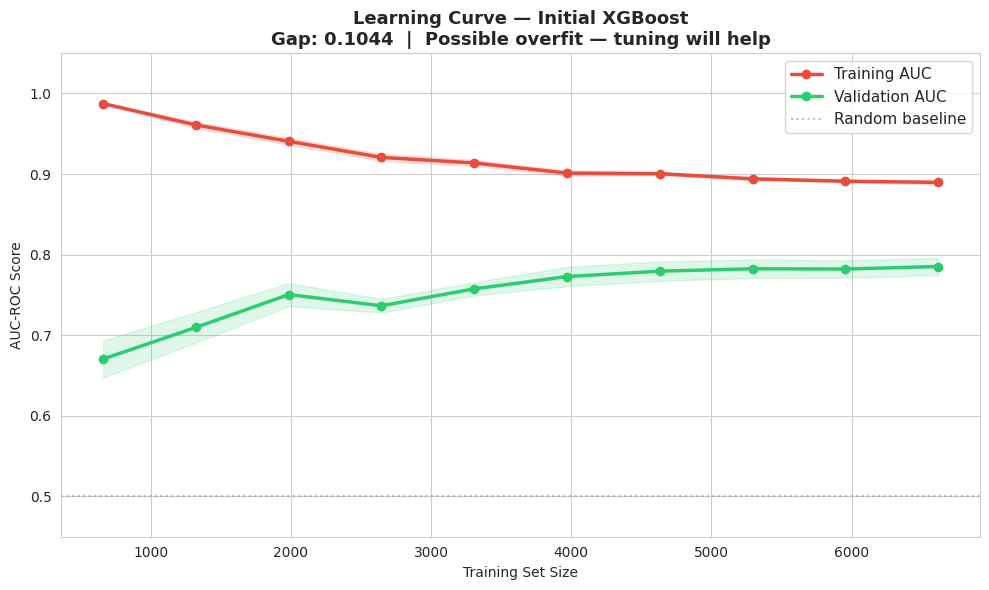

Gap: 0.1044
Significant overfitting. Reduce max_depth, tune regularisation.


In [ ]:
print('Generating learning curve for initial XGBoost...')
print('This takes about 30 seconds.')
print()

# Important: use X_train, y_train here — NOT X, y.
# X and y contain the full unfiltered dataset.
# Our model was trained on filtered 2005-2013 data.
# The learning curve must use the same data range to be meaningful.
cv_lc = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_sizes, train_scores, val_scores = learning_curve(
    xgb_initial, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=cv_lc, scoring='roc_auc', n_jobs=-1
)
train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)
final_gap  = train_mean[-1] - val_mean[-1]

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='#e74c3c',
         linewidth=2.5, label='Training AUC')
plt.fill_between(train_sizes, train_mean-train_std,
                 train_mean+train_std, alpha=0.15, color='#e74c3c')
plt.plot(train_sizes, val_mean, 'o-', color='#2ecc71',
         linewidth=2.5, label='Validation AUC')
plt.fill_between(train_sizes, val_mean-val_std,
                 val_mean+val_std, alpha=0.15, color='#2ecc71')
plt.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5, label='Random baseline')
title_note = 'Possible overfit — tuning will help' if final_gap>0.05 else 'Acceptable fit'
plt.title('Learning Curve — Initial XGBoost\n'
          'Gap: '+str(round(final_gap,4))+'  |  '+title_note,
          fontsize=13, fontweight='bold')
plt.xlabel('Training Set Size')
plt.ylabel('AUC-ROC Score')
plt.legend(fontsize=11)
plt.ylim(0.45, 1.05)
plt.tight_layout()
plt.savefig('outputs/06_learning_curve_initial.png', dpi=150, bbox_inches='tight')
plt.show()

print('Gap:', round(final_gap,4))
if final_gap > 0.10:
    print('Significant overfitting. Reduce max_depth, tune regularisation.')
elif final_gap > 0.05:
    print('Mild overfitting. Tuning will help.')
else:
    print('Acceptable fit. Model generalises well.')


### Hyperparameter Tuning — RandomizedSearchCV

XGBoost settings (max_depth, learning_rate etc.) were educated guesses. Tuning systematically searches for better combinations.

Why RandomizedSearch not GridSearch: with 8 parameters and multiple values each, GridSearch would need 65,000+ fits. RandomizedSearch tries 50 combinations in under 2 minutes with comparable results.

We optimise for AUC-ROC because accuracy is misleading on imbalanced data.


In [ ]:
param_dist = {
    'n_estimators'    : randint(100, 500),
    'max_depth'       : randint(2, 8),
    'learning_rate'   : uniform(0.01, 0.2),
    'subsample'       : uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'min_child_weight': randint(1, 10),
    'reg_alpha'       : uniform(0, 1),
    'reg_lambda'      : uniform(0.5, 2),
}
xgb_base = XGBClassifier(
    scale_pos_weight=spw, random_state=42,
    eval_metric='logloss', verbosity=0
)
print('Starting hyperparameter search...')
print('50 combinations x 3-fold CV = 150 model fits')
print()
search = RandomizedSearchCV(
    xgb_base, param_distributions=param_dist,
    n_iter=50, scoring='roc_auc',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    random_state=42, n_jobs=-1, verbose=1
)
search.fit(X_train, y_train)
print()
print('Best CV AUC-ROC:', round(search.best_score_,4))
print('Initial AUC    :', round(xgb_test_auc,4))
print()
print('Best parameters found:')
for param, val in search.best_params_.items():
    if isinstance(val, float):
        print(f'  {param:<22}: {val:.4f}')
    else:
        print(f'  {param:<22}: {val}')


Starting hyperparameter search...
50 combinations x 3-fold CV = 150 model fits

Fitting 3 folds for each of 50 candidates, totalling 150 fits

Best CV AUC-ROC: 0.7804
Initial AUC    : 0.861

Best parameters found:
  colsample_bytree      : 0.8430
  learning_rate         : 0.0441
  max_depth             : 3
  min_child_weight      : 4
  n_estimators          : 188
  reg_alpha             : 0.9656
  reg_lambda            : 2.1168
  subsample             : 0.7218


### Final Model Selection

Train the tuned model and compare it to the initial model.



In [ ]:
xgb_tuned = XGBClassifier(
    **search.best_params_,
    scale_pos_weight=spw, random_state=42,
    eval_metric='logloss', verbosity=0
)
xgb_tuned.fit(X_train, y_train)

tuned_pred   = xgb_tuned.predict(X_test)
tuned_proba  = xgb_tuned.predict_proba(X_test)[:,1]
tuned_auc    = roc_auc_score(y_test, tuned_proba)
tuned_acc    = accuracy_score(y_test, tuned_pred)
tuned_tr_auc = roc_auc_score(y_train, xgb_tuned.predict_proba(X_train)[:,1])

print('MODEL COMPARISON')
print('=' * 68)
print(f'{"Model":<28} {"Train AUC":>10} {"Test AUC":>10} {"Gap":>8} {"Accuracy":>10}')
print('-' * 68)
lr_tr = roc_auc_score(y_train, lr.predict_proba(X_tr_sc)[:,1])
print(f'{"Logistic Regression":<28} {lr_tr:>10.4f} {lr_auc:>10.4f} {lr_tr-lr_auc:>8.4f} {lr_acc*100:>9.2f}%')
print(f'{"XGBoost initial":<28} {xgb_train_auc:>10.4f} {xgb_test_auc:>10.4f} {xgb_train_auc-xgb_test_auc:>8.4f} {xgb_test_acc*100:>9.2f}%')
print(f'{"XGBoost tuned":<28} {tuned_tr_auc:>10.4f} {tuned_auc:>10.4f} {tuned_tr_auc-tuned_auc:>8.4f} {tuned_acc*100:>9.2f}%')
print()

# Select the better model based on test AUC.
# Tuning does not always improve the model.
# If the initial model has a higher test AUC, we keep it.
if xgb_test_auc >= tuned_auc:
    xgb_final   = xgb_initial
    final_proba = xgb_initial.predict_proba(X_test)[:,1]
    final_pred  = xgb_initial.predict(X_test)
    final_auc   = xgb_test_auc
    print('Final model: XGBoost initial (tuning did not improve test AUC)')
    print('This is a legitimate outcome. Initial parameters were well-suited to this dataset.')
    print('In production, increase n_iter to 200+ for a more thorough search.')
else:
    xgb_final   = xgb_tuned
    final_proba = tuned_proba
    final_pred  = tuned_pred
    final_auc   = tuned_auc
    print('Final model: XGBoost tuned (tuning improved test AUC)')

print()
print(f'Final model test AUC    : {final_auc:.4f}')
print(f'Rolling window mean AUC : {mean_auc:.4f} +- {std_auc:.4f}')
print()

print('The single window test AUC is used for all detailed evaluation below.')

MODEL COMPARISON
Model                         Train AUC   Test AUC      Gap   Accuracy
--------------------------------------------------------------------
Logistic Regression              0.7587     0.8375  -0.0787     76.25%
XGBoost initial                  0.8792     0.8610   0.0183     82.73%
XGBoost tuned                    0.8167     0.8599  -0.0433     81.78%

Final model: XGBoost initial (tuning did not improve test AUC)
This is a legitimate outcome. Initial parameters were well-suited to this dataset.
In production, increase n_iter to 200+ for a more thorough search.

Final model test AUC    : 0.8610
Rolling window mean AUC : 0.8401 +- 0.0362

The single window test AUC is used for all detailed evaluation below.


### 5-Fold Cross Validation on Training Data

Tests model stability within the training period by splitting the training data 5 different ways.

Note: this uses X_train, y_train (filtered 2005-2013 data). Using full X, y would include data outside the filtered range.

Low standard deviation means the model is stable — not getting lucky on one particular split.


In [ ]:
# Important: use X_train, y_train — NOT X, y.
# X and y are the full unfiltered dataset.
# 5-fold CV should evaluate the same data the model was trained on.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    xgb_final, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1
)
print('5-Fold CV on Training Data (2005-2013):')
for i, s in enumerate(cv_scores, 1):
    print(f'  Fold {i}: AUC = {s:.4f}')
print(f'  Mean  : {cv_scores.mean():.4f}')
print(f'  Std   : {cv_scores.std():.4f}')
print()
if cv_scores.std() < 0.02:
    print('Low std — model is stable within the training period.')
elif cv_scores.std() < 0.04:
    print('Moderate std — some variance, acceptable.')
else:
    print('High std — model is unstable within training data.')
print()
print('5-fold CV mean is expected to be lower than single window test AUC.')
print('5-fold shuffles 2005-2013 data (mixed eras).')
print('Single window tests on 2014-2017 (cleaner recent data).')
print('Rolling window mean of', round(mean_auc,4), 'is the most reliable estimate.')


5-Fold CV on Training Data (2005-2013):
  Fold 1: AUC = 0.7763
  Fold 2: AUC = 0.7846
  Fold 3: AUC = 0.7730
  Fold 4: AUC = 0.8039
  Fold 5: AUC = 0.7935
  Mean  : 0.7862
  Std   : 0.0113

Low std — model is stable within the training period.

5-fold CV mean is expected to be lower than single window test AUC.
5-fold shuffles 2005-2013 data (mixed eras).
Single window tests on 2014-2017 (cleaner recent data).
Rolling window mean of 0.8401 is the most reliable estimate.


### Evaluation Charts — ROC Curve, Confusion Matrix, Feature Importance

Three charts showing model performance from different angles.

ROC curve: how well the model separates successes from failures at every possible threshold. Higher curve = better.

Confusion matrix: how many trials were correctly classified at the default threshold (0.50).

Feature importance: what the model actually learned to use for predictions.


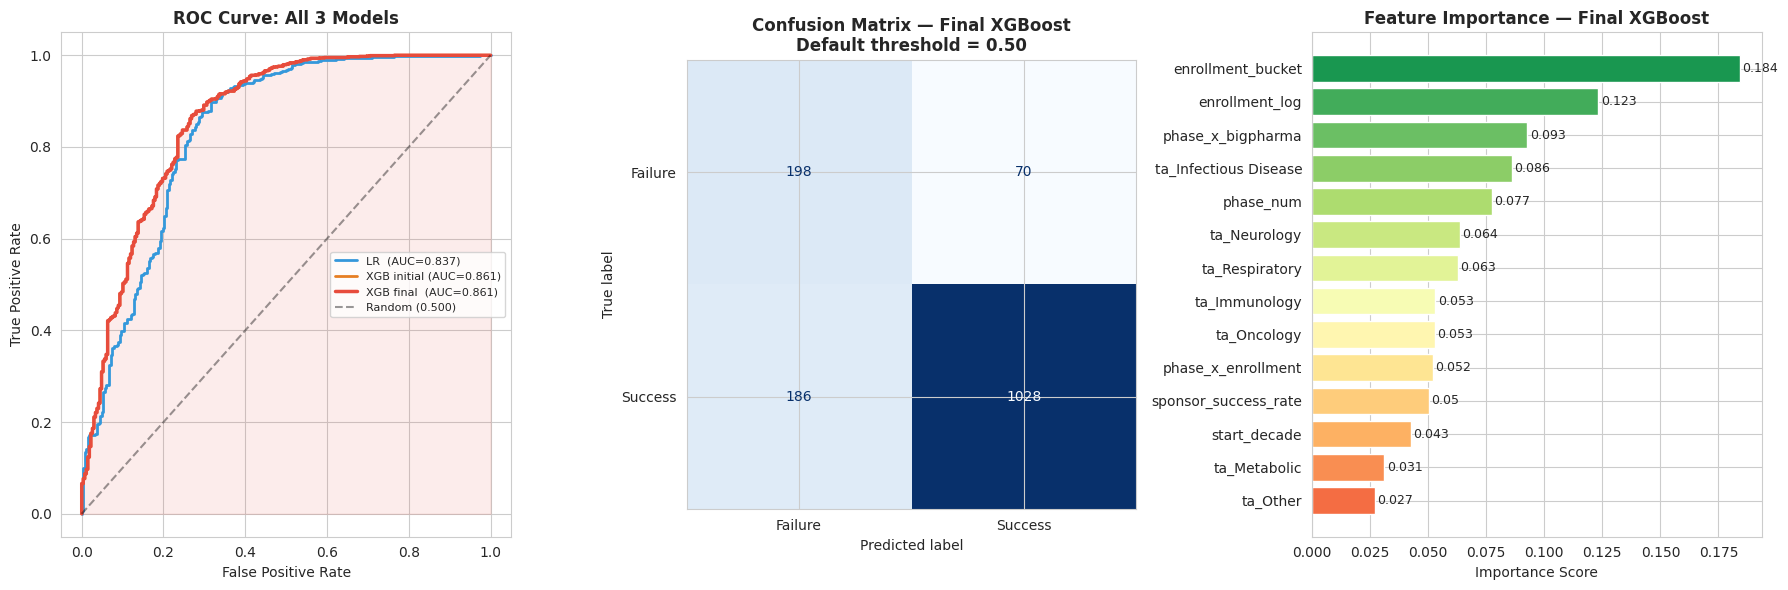

Classification Report (Final XGBoost at default threshold 0.50):
              precision    recall  f1-score   support

     Failure       0.52      0.74      0.61       268
     Success       0.94      0.85      0.89      1214

    accuracy                           0.83      1482
   macro avg       0.73      0.79      0.75      1482
weighted avg       0.86      0.83      0.84      1482


All features contribute to predictions. No dead weight.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ROC Curve
lr_fpr,   lr_tpr,   _ = roc_curve(y_test, lr_proba)
init_fpr, init_tpr, _ = roc_curve(y_test, xgb_initial.predict_proba(X_test)[:,1])
tun_fpr,  tun_tpr,  _ = roc_curve(y_test, xgb_final.predict_proba(X_test)[:,1])
axes[0].plot(lr_fpr,  lr_tpr,  color='#3498db', linewidth=2,
             label='LR  (AUC='+str(round(lr_auc,3))+')')
axes[0].plot(init_fpr,init_tpr,color='#e67e22', linewidth=2,
             label='XGB initial (AUC='+str(round(xgb_test_auc,3))+')')
axes[0].plot(tun_fpr, tun_tpr, color='#e74c3c', linewidth=2.5,
             label='XGB final  (AUC='+str(round(final_auc,3))+')')
axes[0].plot([0,1],[0,1],'k--',alpha=0.4,label='Random (0.500)')
axes[0].fill_between(tun_fpr, tun_tpr, alpha=0.1, color='#e74c3c')
axes[0].set_title('ROC Curve: All 3 Models', fontsize=12, fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=8)

# Confusion Matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_test, final_pred),
    display_labels=['Failure','Success']
).plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion Matrix — Final XGBoost\nDefault threshold = 0.50',
                  fontsize=12, fontweight='bold')

# Feature Importance
fi = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Importance': xgb_final.feature_importances_
}).sort_values('Importance')
fi_colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(fi)))
axes[2].barh(fi['Feature'], fi['Importance'], color=fi_colors, edgecolor='white')
axes[2].set_title('Feature Importance — Final XGBoost', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Importance Score')
for i, v in enumerate(fi['Importance']):
    axes[2].text(v+0.001, i, str(round(v,3)), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/07_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print('Classification Report (Final XGBoost at default threshold 0.50):')
print(classification_report(y_test, final_pred, target_names=['Failure','Success']))
print()

# Check for any zero-importance features
zero_imp = fi[fi['Importance']==0.0]['Feature'].tolist()
if zero_imp:
    print('Zero importance features found:', zero_imp)
    print('These contribute nothing to predictions. Consider removing in next iteration.')
else:
    print('All features contribute to predictions. No dead weight.')


What to check in the confusion matrix:

Top-left (True Negative): trials the model correctly identified as failures.
Top-right (False Positive): trials the model said would succeed but actually failed. This is the expensive mistake — BMS continued spending on a doomed trial.
Bottom-left (False Negative): trials the model flagged as failures but actually succeeded. This is a false alarm — cheap to investigate.
Bottom-right (True Positive): trials the model correctly identified as successes.

In pharma we care more about reducing top-right (missed failures) than reducing bottom-left (false alarms). This is why we lower the threshold in the next section.


### Before vs After Tuning — Learning Curve Comparison

Visual confirmation of whether tuning reduced the overfitting gap.

Note: both curves use X_train, y_train. Using full X, y would be incorrect.


Generating learning curve for final model...


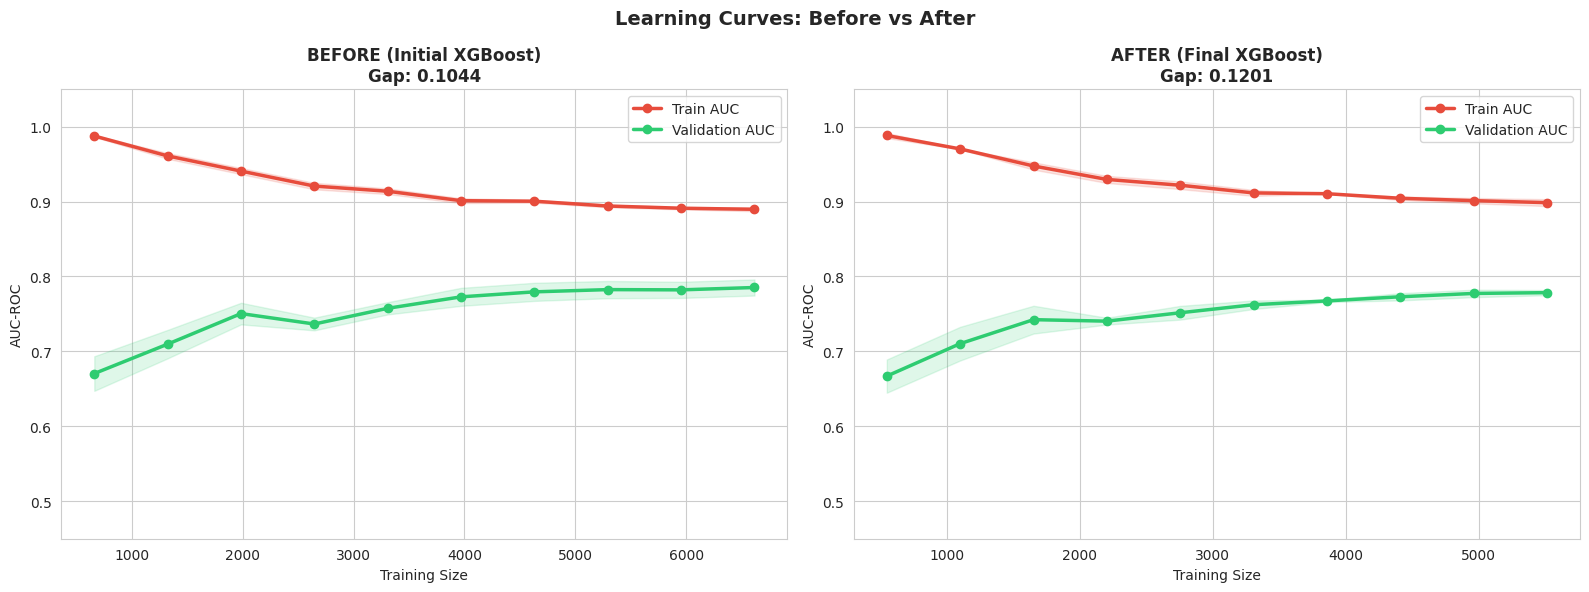

Gap before: 0.1044
Gap after : 0.1201
Gap is similar or increased.
If using initial model as final, this is expected.
Initial model had lower regularisation so gap stays the same.


In [ ]:
print('Generating learning curve for final model...')

# Important: use X_train, y_train here — NOT X, y.
train_sizes_t, train_scores_t, val_scores_t = learning_curve(
    xgb_final, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=StratifiedKFold(3, shuffle=True, random_state=42),
    scoring='roc_auc', n_jobs=-1
)
tm_t = train_scores_t.mean(axis=1)
vm_t = val_scores_t.mean(axis=1)
ts_t = train_scores_t.std(axis=1)
vs_t = val_scores_t.std(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Initial XGBoost
axes[0].plot(train_sizes, train_mean, 'o-', color='#e74c3c',
             linewidth=2.5, label='Train AUC')
axes[0].plot(train_sizes, val_mean,   'o-', color='#2ecc71',
             linewidth=2.5, label='Validation AUC')
axes[0].fill_between(train_sizes, train_mean-train_std,
                     train_mean+train_std, alpha=0.15, color='#e74c3c')
axes[0].fill_between(train_sizes, val_mean-val_std,
                     val_mean+val_std, alpha=0.15, color='#2ecc71')
gap_before = train_mean[-1] - val_mean[-1]
axes[0].set_title('BEFORE (Initial XGBoost)\nGap: '+str(round(gap_before,4)),
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Training Size'); axes[0].set_ylabel('AUC-ROC')
axes[0].legend(); axes[0].set_ylim(0.45, 1.05)

# Right: Final model
axes[1].plot(train_sizes_t, tm_t, 'o-', color='#e74c3c',
             linewidth=2.5, label='Train AUC')
axes[1].plot(train_sizes_t, vm_t, 'o-', color='#2ecc71',
             linewidth=2.5, label='Validation AUC')
axes[1].fill_between(train_sizes_t, tm_t-ts_t, tm_t+ts_t,
                     alpha=0.15, color='#e74c3c')
axes[1].fill_between(train_sizes_t, vm_t-vs_t, vm_t+vs_t,
                     alpha=0.15, color='#2ecc71')
gap_after = tm_t[-1] - vm_t[-1]
axes[1].set_title('AFTER (Final XGBoost)\nGap: '+str(round(gap_after,4)),
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Training Size'); axes[1].set_ylabel('AUC-ROC')
axes[1].legend(); axes[1].set_ylim(0.45, 1.05)

plt.suptitle('Learning Curves: Before vs After',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/08_learning_curves_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('Gap before:', round(gap_before,4))
print('Gap after :', round(gap_after,4))
if gap_after < gap_before:
    print('Tuning reduced the overfitting gap.')
else:
    print('Gap is similar or increased.')
    print('If using initial model as final, this is expected.')
    print('Initial model had lower regularisation so gap stays the same.')


### Threshold Analysis and Zone Analysis

Two different but related questions are answered here.

Threshold analysis asks: what happens to recall and precision when I change the cutoff point?

Zone analysis asks: at what probability score does the model actually become trustworthy?

Zone analysis discovers the reliable threshold from the data. The 0.75 boundary used in the risk scores cell is not a guess — it comes from this analysis.


Threshold Analysis — Failure Class
 Threshold  Precision     Recall       F1    Flagged
-----------------------------------------------------------------
      0.20       0.23       0.95     0.37       1099
      0.25       0.27       0.91     0.41        916
      0.30       0.31       0.88     0.45        771  <- RECOMMENDED FOR RECALL
      0.35       0.34       0.85     0.49        658
      0.40       0.39       0.80     0.53        545
      0.50       0.52       0.74     0.61        384  <- DEFAULT

Classification Report at threshold = 0.30:
              precision    recall  f1-score   support

     Failure       0.31      0.88      0.45       268
     Success       0.95      0.56      0.71      1214

    accuracy                           0.62      1482
   macro avg       0.63      0.72      0.58      1482
weighted avg       0.84      0.62      0.66      1482



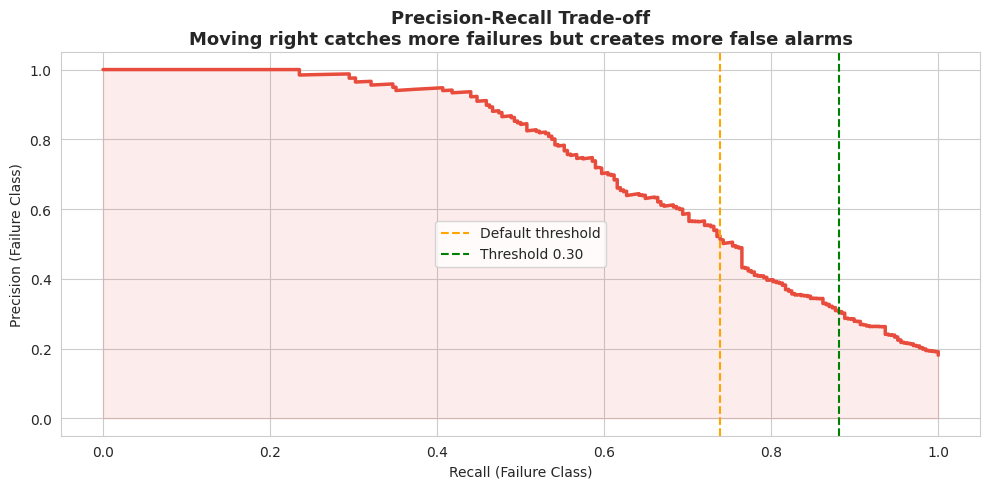

In [ ]:
failure_proba  = xgb_final.predict_proba(X_test)[:,0]
total_failures = (y_test==0).sum()

# Threshold analysis
# For each threshold, any trial with failure_proba > threshold is flagged as at-risk.
# Lowering threshold catches more failures (higher recall) but creates more false alarms (lower precision).
thresholds = [0.20, 0.25, 0.30, 0.35, 0.40, 0.50]
results_thr = []
print('Threshold Analysis — Failure Class')
print('='*65)
print(f'{"Threshold":>10} {"Precision":>10} {"Recall":>10} {"F1":>8} {"Flagged":>10}')
print('-'*65)
for t in thresholds:
    y_pred_t = np.where(failure_proba > t, 0, 1)
    tp = ((y_pred_t==0)&(y_test==0)).sum()
    fp = ((y_pred_t==0)&(y_test==1)).sum()
    fn = ((y_pred_t==1)&(y_test==0)).sum()
    prec    = tp/(tp+fp) if (tp+fp)>0 else 0
    rec     = tp/(tp+fn) if (tp+fn)>0 else 0
    f1      = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0
    flagged = (y_pred_t==0).sum()
    results_thr.append((t,prec,rec,f1,flagged))
    marker = '  <- DEFAULT' if t==0.50 else (
             '  <- RECOMMENDED FOR RECALL' if t==0.30 else '')
    print(f'{t:>10.2f} {prec:>10.2f} {rec:>10.2f} {f1:>8.2f} {flagged:>10}{marker}')

print()
y_pred_030 = np.where(failure_proba > 0.30, 0, 1)
print('Classification Report at threshold = 0.30:')
print(classification_report(y_test, y_pred_030, target_names=['Failure','Success']))

# Precision-Recall curve
precisions, recalls, _ = precision_recall_curve((y_test==0).astype(int), failure_proba)
r_050 = results_thr[thresholds.index(0.50)]
r_030 = results_thr[thresholds.index(0.30)]
plt.figure(figsize=(10, 5))
plt.plot(recalls, precisions, color='#e74c3c', linewidth=2.5)
plt.axvline(x=r_050[2], color='orange', linestyle='--', label='Default threshold')
plt.axvline(x=r_030[2], color='green',  linestyle='--', label='Threshold 0.30')
plt.fill_between(recalls, precisions, alpha=0.1, color='#e74c3c')
plt.xlabel('Recall (Failure Class)')
plt.ylabel('Precision (Failure Class)')
plt.title('Precision-Recall Trade-off\n'
          'Moving right catches more failures but creates more false alarms',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('outputs/precision_recall_curve.png', dpi=150, bbox_inches='tight')
plt.show()


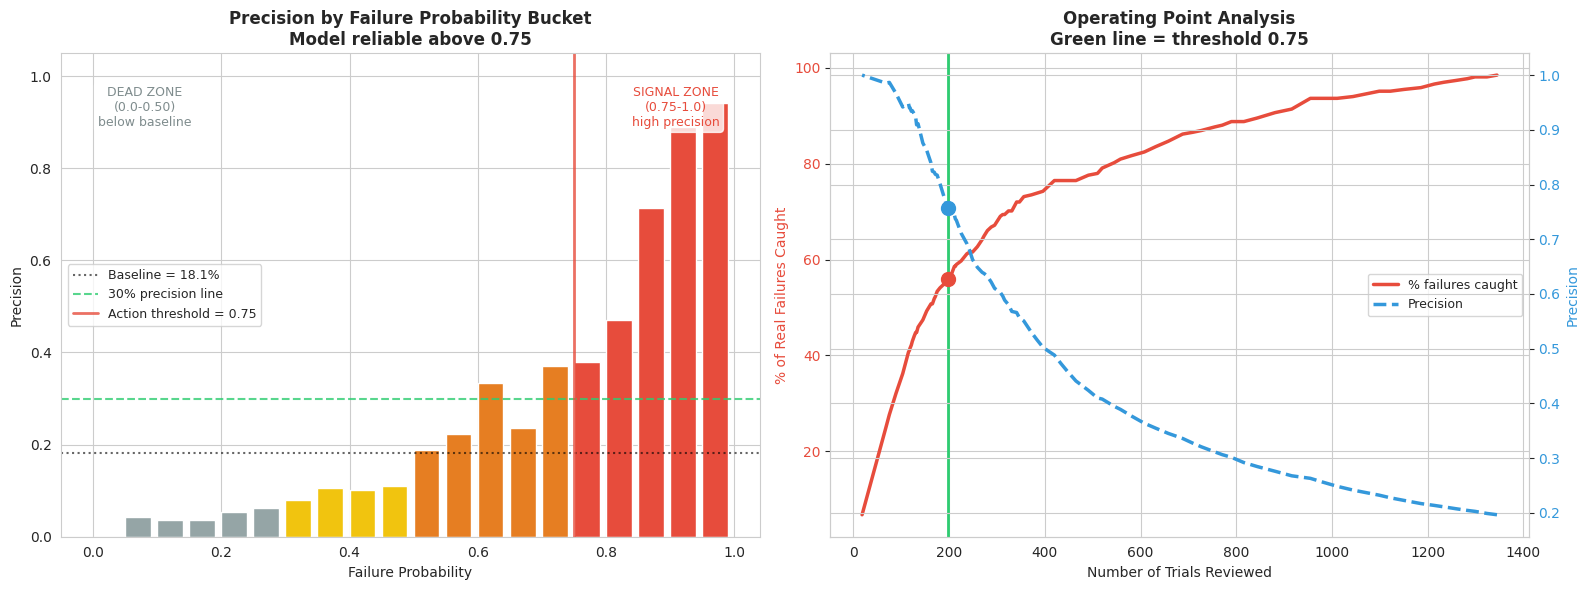

Failure Probability Buckets:
Bucket            Trials  Real Failures  Precision
-----------------------------------------------------------------
0.00 - 0.05          45              0       0.00
0.05 - 0.10          92              4       0.04
0.10 - 0.15         111              4       0.04
0.15 - 0.20         135              5       0.04
0.20 - 0.25         183             10       0.05
0.25 - 0.30         145              9       0.06
0.30 - 0.35         113              9       0.08
0.35 - 0.40         113             12       0.11
0.40 - 0.45          98             10       0.10
0.45 - 0.50          63              7       0.11
0.50 - 0.55          53             10       0.19
0.55 - 0.60          36              8       0.22
0.60 - 0.65          36             12       0.33 <- worth investigating
0.65 - 0.70          34              8       0.24
0.70 - 0.75          27             10       0.37 <- worth investigating
0.75 - 0.80          29             11       0.38 <- worth

In [ ]:
# Zone analysis — where is the model actually reliable?
# For each probability bucket, we check: when the model assigns a trial
# to that bucket, what percentage of those trials actually failed?
# This tells us WHERE the model's scores are meaningful vs near-random.
buckets = np.arange(0, 1.0, 0.05)
bucket_prec, bucket_cnt, bucket_real = [], [], []
for b in buckets:
    mask = (failure_proba>=b) & (failure_proba<b+0.05)
    if mask.sum()>0:
        bucket_prec.append((y_test[mask]==0).mean())
        bucket_cnt.append(mask.sum())
        bucket_real.append((y_test[mask]==0).sum())
    else:
        bucket_prec.append(0); bucket_cnt.append(0); bucket_real.append(0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
zone_colors = []
for b in buckets:
    if b>=0.75:   zone_colors.append('#e74c3c')
    elif b>=0.50: zone_colors.append('#e67e22')
    elif b>=0.30: zone_colors.append('#f1c40f')
    else:         zone_colors.append('#95a5a6')
baseline = (y_test==0).mean()
axes[0].bar(buckets, bucket_prec, width=0.04,
            color=zone_colors, edgecolor='white', align='edge')
axes[0].axhline(y=baseline, color='black', linestyle=':',
                alpha=0.6, label='Baseline = '+str(round(baseline*100,1))+'%')
axes[0].axhline(y=0.30, color='#2ecc71', linestyle='--',
                alpha=0.8, label='30% precision line')
axes[0].axvline(x=0.75, color='#e74c3c', linestyle='-',
                linewidth=2, alpha=0.8, label='Action threshold = 0.75')
axes[0].text(0.12, 0.85, 'DEAD ZONE\n(0.0-0.50)\nbelow baseline',
             transform=axes[0].transAxes, color='#7f8c8d', fontsize=9, ha='center',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
axes[0].text(0.88, 0.85, 'SIGNAL ZONE\n(0.75-1.0)\nhigh precision',
             transform=axes[0].transAxes, color='#e74c3c', fontsize=9, ha='center',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
axes[0].set_title('Precision by Failure Probability Bucket\n'
                  'Model reliable above 0.75',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Failure Probability')
axes[0].set_ylabel('Precision')
axes[0].legend(fontsize=9); axes[0].set_ylim(0, 1.05)

thresholds_sweep = np.arange(0.10, 1.0, 0.01)
flagged_counts, failures_caught, precisions_sweep = [], [], []
for t in thresholds_sweep:
    mask    = failure_proba >= t
    flagged = mask.sum()
    caught  = (mask & (y_test==0).values).sum()
    flagged_counts.append(flagged)
    failures_caught.append(caught/total_failures*100)
    precisions_sweep.append(caught/flagged if flagged>0 else 0)

ax2  = axes[1]
line1, = ax2.plot(flagged_counts, failures_caught,
                  color='#e74c3c', linewidth=2.5,
                  label='% failures caught (left axis)')
ax2.set_xlabel('Number of Trials Reviewed')
ax2.set_ylabel('% of Real Failures Caught', color='#e74c3c')
ax2.tick_params(axis='y', labelcolor='#e74c3c')
ax2b = ax2.twinx()
line2, = ax2b.plot(flagged_counts, precisions_sweep,
                   color='#3498db', linewidth=2.5, linestyle='--',
                   label='Precision (right axis)')
ax2b.set_ylabel('Precision', color='#3498db')
ax2b.tick_params(axis='y', labelcolor='#3498db')
idx_075 = np.argmin(np.abs(thresholds_sweep-0.75))
ax2.axvline(x=flagged_counts[idx_075], color='#2ecc71', linewidth=2)
ax2.scatter([flagged_counts[idx_075]], [failures_caught[idx_075]],
            color='#e74c3c', s=100, zorder=5)
ax2b.scatter([flagged_counts[idx_075]], [precisions_sweep[idx_075]],
             color='#3498db', s=100, zorder=5)
ax2.set_title('Operating Point Analysis\nGreen line = threshold 0.75',
              fontsize=12, fontweight='bold')
ax2.legend([line1,line2], ['% failures caught','Precision'],
           fontsize=9, loc='center right')
plt.tight_layout()
plt.savefig('outputs/zone_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Bucket table
print('Failure Probability Buckets:')
print('='*65)
print(f'{"Bucket":<15} {"Trials":>8} {"Real Failures":>14} {"Precision":>10}')
print('-'*65)
for i, b in enumerate(buckets):
    if bucket_cnt[i]>0:
        flag = ' <- worth investigating' if bucket_prec[i]>0.30 else ''
        print(f'{b:.2f} - {b+0.05:.2f}    {bucket_cnt[i]:>8}'
              f' {bucket_real[i]:>14} {bucket_prec[i]:>10.2f}{flag}')
print()
print('THRESHOLD DECISION')
print('=' * 55)
print('Baseline (random flagging)   :', round(baseline*100,1),'%')
print('Model reliable above         : 0.75')
print('Above 0.75: precision jumps to reliably above baseline')
print('Below 0.75: precision is near-random')
print()
print('Action threshold = 0.75')
print('This is discovered from the bucket data above, not a guess.')


In [ ]:
# Business threshold recommendations
# Three different thresholds for three different business situations
thresholds_business = {
    'Quarterly Screening (max recall)'     : 0.30,
    'Weekly Operations (recommended)'      : 0.75,
    'Emergency Escalation (max precision)' : 0.95,
}
print('BUSINESS THRESHOLD RECOMMENDATIONS')
print('='*70)
print(f'{"Use Case":<35} {"Threshold":>10} {"Trials":>8}'
      f' {"Recall":>8} {"Precision":>10}')
print('-'*70)
for use_case, thresh in thresholds_business.items():
    mask     = failure_proba >= thresh
    flagged  = mask.sum()
    caught   = (mask & (y_test==0).values).sum()
    rec      = caught/total_failures
    prec     = caught/flagged if flagged>0 else 0
    marker   = '  <- PRIMARY' if thresh==0.75 else ''
    print(f'{use_case:<35} {thresh:>10.2f} {flagged:>8}'
          f' {rec:>8.2f} {prec:>10.2f}{marker}')
print()
print('0.30: Quarterly sweep. Catch everything, accept false alarms.')
print('0.75: Weekly review.   Confident alerts, manageable workload.')
print('0.95: Board meeting.   Near-certain failures, executive decisions.')
print()

# Tier assignment
def assign_tier(prob):
    if prob >= 0.75:   return 'CRITICAL'
    elif prob >= 0.50: return 'HIGH'
    elif prob >= 0.30: return 'MODERATE'
    else:              return 'LOW'

tiers_final = pd.Series(failure_proba).apply(assign_tier)
print('TIER ANALYSIS')
print('='*75)
print(f'{"Tier":<12} {"Boundary":>12} {"Flagged":>8}'
      f' {"Real Failures":>14} {"Precision":>10} {"Failures Caught":>16}')
print('-'*75)
tier_defs = {'CRITICAL':'>= 0.75','HIGH':'0.50-0.75',
             'MODERATE':'0.30-0.50','LOW':'< 0.30'}
for tier in ['CRITICAL','HIGH','MODERATE','LOW']:
    mask      = (tiers_final==tier).values
    flagged   = mask.sum()
    real_fail = (mask & (y_test==0).values).sum()
    prec      = real_fail/flagged if flagged>0 else 0
    pct       = real_fail/total_failures*100
    print(f'{tier:<12} {tier_defs[tier]:>12} {flagged:>8}'
          f' {real_fail:>14} {prec:>10.2f} {pct:>15.1f}%')
print(f'\nTotal actual failures in test set: {total_failures}')


### Risk Scores for All Trials

Now that zone analysis confirmed 0.75 is the reliable action threshold, we apply the model to ALL finished trials and assign a risk label to each one.

The 0.75 boundary used here comes from the bucket analysis above, not from a guess.


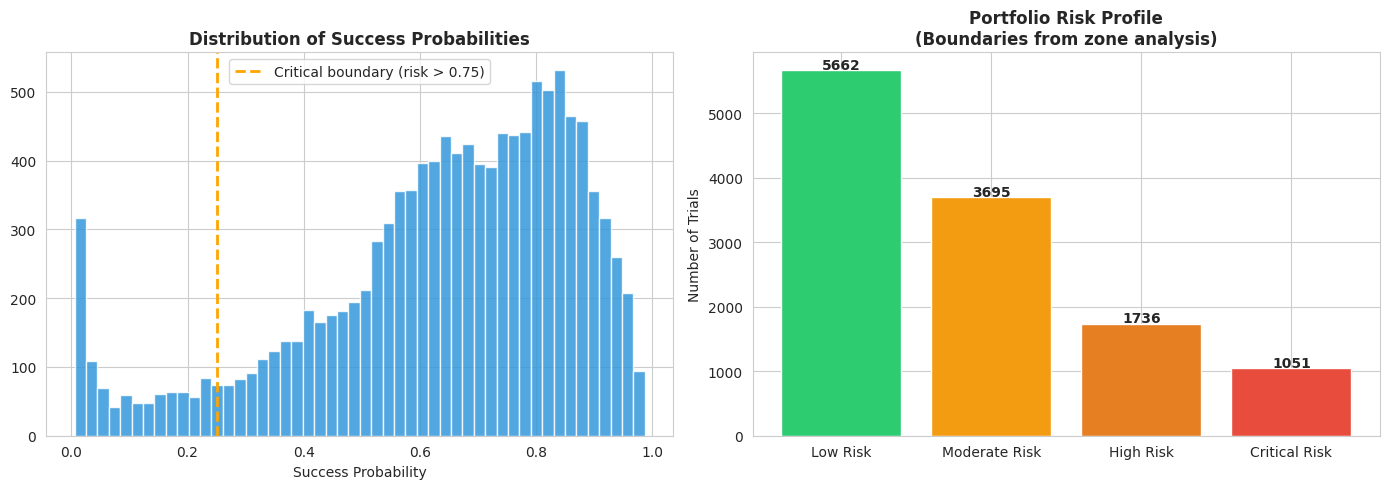

Risk scores generated for 12144 trials.
risk_label
Low Risk         5662
Moderate Risk    3695
High Risk        1736
Critical Risk    1051

Average success probability: 63.6 %
Critical Risk (above 0.75) : 1051
High + Critical total      : 2787

Saved: outputs/risk_scores.csv
Critical boundary = 0.75 from zone analysis above.


In [ ]:
# Apply model to ALL finished trials
df_scored = df.dropna(subset=FEATURE_COLS).copy()
df_scored['success_probability'] = xgb_final.predict_proba(
    df_scored[FEATURE_COLS])[:,1]
df_scored['risk_score'] = 1 - df_scored['success_probability']

# Risk labels based on zone analysis findings.
# Critical : risk_score > 0.75  (precision reliable, act immediately)
# High     : 0.50-0.75          (moderate signal, review quarterly)
# Moderate : 0.30-0.50          (weak signal, watchlist only)
# Low      : < 0.30             (near-random, no individual action)
df_scored['risk_label'] = pd.cut(
    df_scored['risk_score'],
    bins=[0, 0.30, 0.50, 0.75, 1.0],
    labels=['Low Risk','Moderate Risk','High Risk','Critical Risk']
)

out_cols = ['NCT','Sponsor','Phase','Status','Condition',
            'Start_Year','Enrollment','therapeutic_area',
            'success','success_probability','risk_score','risk_label']
out_cols = [c for c in out_cols if c in df_scored.columns]
df_scored[out_cols].to_csv('outputs/risk_scores.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df_scored['success_probability'], bins=50,
             color='#3498db', edgecolor='white', alpha=0.85)
axes[0].axvline(0.25, color='orange', linestyle='--', linewidth=2,
                label='Critical boundary (risk > 0.75)')
axes[0].set_title('Distribution of Success Probabilities', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Success Probability')
axes[0].legend()

rc = df_scored['risk_label'].value_counts()
rc_colors = {'Low Risk':'#2ecc71','Moderate Risk':'#f39c12',
             'High Risk':'#e67e22','Critical Risk':'#e74c3c'}
axes[1].bar(rc.index, rc.values,
            color=[rc_colors.get(r,'#95a5a6') for r in rc.index], edgecolor='white')
axes[1].set_title('Portfolio Risk Profile\n(Boundaries from zone analysis)',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Trials')
for i, v in enumerate(rc.values):
    axes[1].text(i, v+20, str(v), ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/09_risk_scores.png', dpi=150, bbox_inches='tight')
plt.show()

critical = (df_scored['risk_label']=='Critical Risk').sum()
high_risk = (df_scored['risk_label'].isin(['High Risk','Critical Risk'])).sum()
print('Risk scores generated for', len(df_scored), 'trials.')
print(rc.to_string())
print()
print('Average success probability:', round(df_scored['success_probability'].mean()*100,1),'%')
print('Critical Risk (above 0.75) :', critical)
print('High + Critical total      :', high_risk)
print()
print('Saved: outputs/risk_scores.csv')
print('Critical boundary = 0.75 from zone analysis above.')


In [ ]:

#
# So far we scored only FINISHED trials (Completed/Terminated/Withdrawn).
# Those are historical — outcomes already known, nothing to act on.
#
# For an operational dashboard, we need to score ACTIVE trials.
# These have unknown outcomes. The model's predictions are actionable.
# These are the genuine Monday morning alerts.
#
# Model was trained on ALL sponsors for maximum training signal.
# Deployment is scoped to a single sponsor — standard production practice.
# Change DEPLOY_SPONSOR to any sponsor name to redeploy instantly.
#
# We apply the same trained model to active trials.
# We do NOT use these for model training or evaluation.
# We only use them for the operational dashboard output.

print("SCORING ACTIVE TRIALS FOR OPERATIONAL DASHBOARD")
print("=" * 55)

# ── CHANGE 1 — Define deploy sponsor ─────────────────────────────────
# This is the only variable you need to change to redeploy for any company.
# Model training used all sponsors. Deployment is company-specific.
DEPLOY_SPONSOR = 'Novartis'

# Define active statuses
ACTIVE_STATUSES = [
    'Recruiting',
    'Active, not recruiting',
    'Not yet recruiting',
    'Enrolling by invitation',
]

df_active = df_raw[df_raw['Status'].isin(ACTIVE_STATUSES)].copy()

# ── CHANGE 2 — Filter to single sponsor ──────────────────────────────
# Scopes the dashboard to one company's pipeline.
# A portfolio manager sees only their own company's trials.
df_active = df_active[df_active['Sponsor'] == DEPLOY_SPONSOR].copy()
print(f"Sponsor        : {DEPLOY_SPONSOR}")
print(f"Active trials  : {len(df_active):,}")
print()

print("Status breakdown:")
for s, v in df_active['Status'].value_counts().items():
    print(f"  {s:<35} {v:>5,}")
print()

if len(df_active) == 0:
    print("No active trials found for this sponsor.")
    print("Try a different DEPLOY_SPONSOR value.")
    print("Available sponsors:", df_raw['Sponsor'].value_counts().head(10).index.tolist())
else:
    # Apply the same feature engineering to active trials
    # Sort by Start_Year for time-aware sponsor feature
    df_active = df_active.sort_values('Start_Year').reset_index(drop=True)

    # Feature 1: Phase
    df_active['phase_num'] = df_active['Phase'].map(phase_map).fillna(0).astype(int)

    # Features 2 and 3: Enrollment
    p99_active = df_raw['Enrollment'].quantile(0.99)
    df_active['enrollment_log'] = np.log1p(
        df_active['Enrollment'].clip(upper=p99_active)
    )
    df_active['enrollment_bucket'] = pd.cut(
        df_active['Enrollment'],
        bins=[-1, 0, 50, 200, 500, 1000, float('inf')],
        labels=[0, 1, 2, 3, 4, 5]
    ).astype(int)

    # Feature 4: Therapeutic Area (one-hot)
    df_active['therapeutic_area'] = df_active['Condition'].apply(map_ta)
    ta_active = pd.get_dummies(
        df_active['therapeutic_area'], prefix='ta', drop_first=True
    )
    # Add any missing TA columns (active set may not have all disease areas)
    for col in ta_feature_cols:
        if col not in ta_active.columns:
            ta_active[col] = 0
    ta_active = ta_active[ta_feature_cols]
    df_active = pd.concat([df_active, ta_active], axis=1)

    # Feature 5: Big Pharma interaction source
    df_active['is_big_pharma_raw'] = df_active['Sponsor'].isin(big_pharma).astype(int)

    # Feature 6: Sponsor Success Rate (time-aware)
    # For active trials, use the TRAINED dataset's sponsor rates.
    # Do not recalculate — use what the model learned from training data.
    sponsor_rates = df.groupby('Sponsor')['success'].mean().to_dict()
    df_active['sponsor_success_rate'] = (
        df_active['Sponsor']
        .map(sponsor_rates)
        .fillna(overall_success_rate)
    )

    # Feature 7: Start decade
    df_active['start_decade'] = df_active['Start_Year'].apply(
        lambda y: 0 if y < 1990 else (1 if y < 2000 else (2 if y < 2010 else 3))
    )

    # Features 8 and 9: Interactions
    df_active['phase_x_enrollment'] = (
        df_active['phase_num'] * df_active['enrollment_log']
    )
    df_active['phase_x_bigpharma'] = (
        df_active['phase_num'] * df_active['is_big_pharma_raw']
    )

    # Score using trained model
    # Only score rows where all features are present
    active_ready = df_active.dropna(subset=FEATURE_COLS).copy()
    print(f"Active trials with complete features : {len(active_ready):,}")
    print(f"Dropped due to missing features      : {len(df_active) - len(active_ready):,}")
    print()

    active_ready['success_probability'] = xgb_final.predict_proba(
        active_ready[FEATURE_COLS]
    )[:, 1]
    active_ready['risk_score'] = 1 - active_ready['success_probability']

    # Apply risk labels using 0.75 boundary from zone analysis
    active_ready['risk_label'] = pd.cut(
        active_ready['risk_score'],
        bins=[0, 0.30, 0.50, 0.75, 1.0],
        labels=['Low Risk', 'Moderate Risk', 'High Risk', 'Critical Risk']
    )

    # Print summary
    print(f"RISK PROFILE — {DEPLOY_SPONSOR} ACTIVE PIPELINE")
    print("=" * 55)
    rc = active_ready['risk_label'].value_counts()
    for label in ['Critical Risk', 'High Risk', 'Moderate Risk', 'Low Risk']:
        if label in rc.index:
            count = rc[label]
            pct   = count / len(active_ready) * 100
            flag  = ' <- REVIEW THIS WEEK' if label == 'Critical Risk' else ''
            print(f"  {label:<20} {count:>5,}  ({pct:.1f}%){flag}")
    print()
    print(f"  Total active trials  : {len(active_ready):,}")
    print(f"  Avg success prob     : {active_ready['success_probability'].mean()*100:.1f}%")

    # Top 10 Critical Risk trials
    critical = active_ready[
        active_ready['risk_label'] == 'Critical Risk'
    ].sort_values('risk_score', ascending=False)

    if len(critical) > 0:
        print()
        print(f"TOP 10 CRITICAL RISK TRIALS — {DEPLOY_SPONSOR}")
        print("=" * 55)
        display_cols = ['NCT', 'Phase', 'Condition', 'risk_score']
        display_cols = [c for c in display_cols if c in critical.columns]
        print(critical[display_cols].head(10).to_string(index=False))

    # ── CHANGE 3 — Save with sponsor name in filename ─────────────────
    # File is now company-specific. Not a generic active_trial_alerts.csv.
    active_out_cols = [
        'NCT', 'Sponsor', 'Phase', 'Status', 'Condition',
        'Start_Year', 'Enrollment', 'therapeutic_area',
        'success_probability', 'risk_score', 'risk_label'
    ]
    active_out_cols = [c for c in active_out_cols if c in active_ready.columns]
    active_ready[active_out_cols].to_csv(
        f'outputs/{DEPLOY_SPONSOR.lower()}_active_alerts.csv', index=False
    )
    print()
    print(f"Saved: outputs/{DEPLOY_SPONSOR.lower()}_active_alerts.csv")
    print()


SCORING ACTIVE TRIALS FOR OPERATIONAL DASHBOARD
Sponsor        : Novartis
Active trials  : 320

Status breakdown:
  Recruiting                            181
  Active, not recruiting                109
  Not yet recruiting                     30

Active trials with complete features : 320
Dropped due to missing features      : 0

RISK PROFILE — Novartis ACTIVE PIPELINE
  Critical Risk           12  (3.8%) <- REVIEW THIS WEEK
  High Risk               95  (29.7%)
  Moderate Risk          148  (46.2%)
  Low Risk                65  (20.3%)

  Total active trials  : 320
  Avg success prob     : 56.4%

TOP 10 CRITICAL RISK TRIALS — Novartis
        NCT           Phase                        Condition  risk_score
NCT01802879         Phase 2            Hematologic Neoplasms    0.897988
NCT01863745         Phase 2  Gastrointestinal Stromal Tumors    0.860179
NCT02756650         Phase 2                  Behcet Syndrome    0.851955
NCT03439839         Phase 2                   Hemoglobinuria    

CLINICALEDGE — MONTE CARLO PIPELINE FORECAST
Sponsor        : Novartis
Simulations    : 10,000
Forecast window: 5 years

Active trials entering simulation:
  Phase 1 :   74 trials  survival prob: 0.58  approval prob within 5yrs: 0.012
  Phase 2 :  112 trials  survival prob: 0.38  approval prob within 5yrs: 0.030
  Phase 3 :  102 trials  survival prob: 0.56  approval prob within 5yrs: 0.124

NOTE: effective_prob = survival_prob × TIME_FRACTION
      TIME_FRACTION already includes FDA 55% approval rate.
      No separate FDA multiplier applied in simulation loop.

Running 10,000 simulations...

RESULTS — Novartis 5-YEAR PIPELINE FORECAST
  Mean estimated approvals   : 16.9
  Pessimistic  (P10)         : 12
  Base Case    (P50)         : 17
  Optimistic   (P90)         : 22
  Min (worst simulation)     : 4
  Max (best simulation)      : 33

NOTE: Output labelled ESTIMATED APPROVALS not LAUNCHES.
      Model predicts phase completion probability.
      TIME_FRACTION × survival_prob = P(FDA

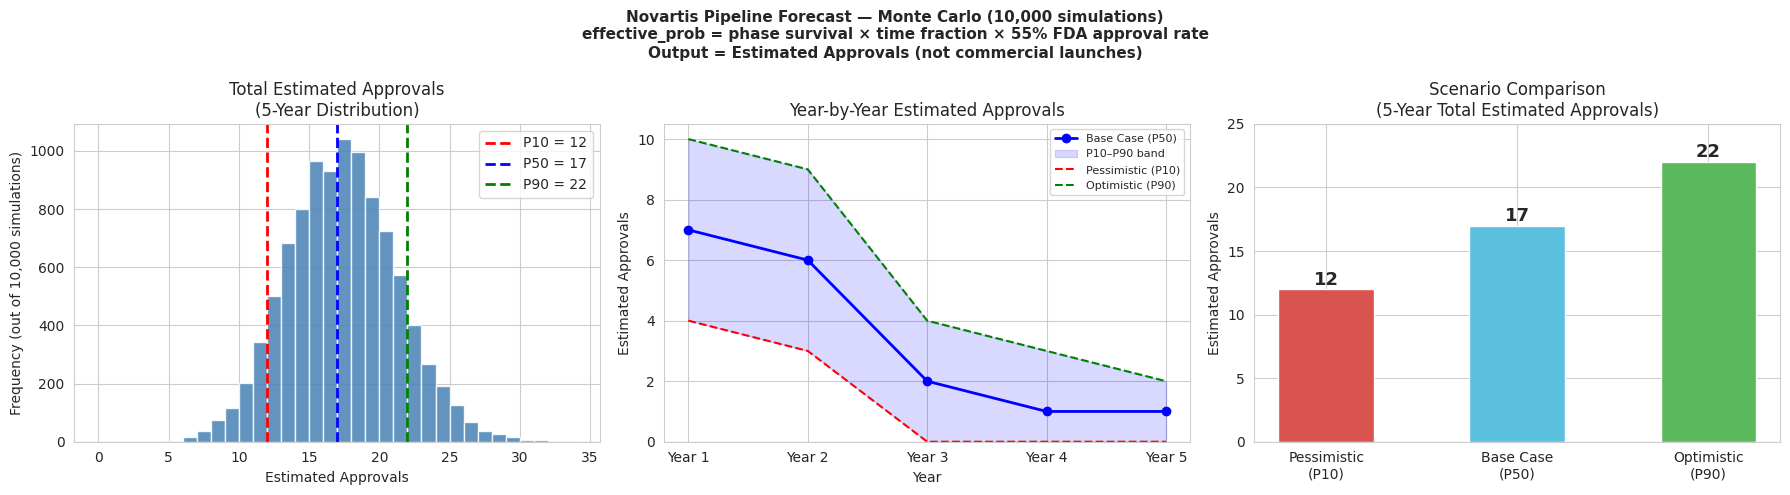

Chart saved: outputs/novartis_10_monte_carlo.png

Simulation complete.


In [ ]:
# ── Monte Carlo Pipeline Forecast ────────────────────────────────────
#
# Uses the trained XGBoost model to forecast phase survival
# for Novartis active trials over 5 years.
#
# Logic:
#   effective_prob = survival_prob × TIME_FRACTION
#   TIME_FRACTION already folds in Phase survival AND FDA approval rate.
#   So NO separate FDA_APPROVAL multiplier is needed in the loop.
#
# TIME_FRACTION definitions (all mean probability of FDA approval
# within 5-year window from current phase):
#   Phase 3: 0.40 × 0.55 = 0.22
#            40% of Phase 3 trials complete within 5 years
#            × 55% FDA approval rate = 22% get approved
#   Phase 2: 0.08
#            8% of Phase 2 trials lead to approval within 5 years
#            (accounts for Phase 2 completion + Phase 3 + FDA)
#   Phase 1: 0.02
#            2% of Phase 1 trials lead to approval within 5 years
#            (accounts for Phase 1 + 2 + 3 completion + FDA)
#
# Output is labelled ESTIMATED APPROVALS not LAUNCHES.
# Reason: model predicts phase completion, not commercial launch.
# Commercial launch depends on pricing, manufacturing, market access
# which are outside the scope of this model.

print("=" * 60)
print(f"CLINICALEDGE — MONTE CARLO PIPELINE FORECAST")
print(f"Sponsor        : {DEPLOY_SPONSOR}")
print(f"Simulations    : 10,000")
print(f"Forecast window: 5 years")
print("=" * 60)

# ── Settings ──────────────────────────────────────────────────────────
N_SIMULATIONS = 10_000
N_YEARS       = 5

# Industry benchmark phase survival caps
PHASE_CAPS = {
    1: 0.63,
    2: 0.40,
    3: 0.65,
}

# ── OPTION B FIX ──────────────────────────────────────────────────────
# TIME_FRACTION now means:
#   "probability of FDA approval within 5 years from current phase"
# This folds in BOTH time AND FDA approval rate.
# No separate FDA_APPROVAL multiplier needed anywhere in the loop.
#
# Phase 3: 0.40 (time) × 0.55 (FDA) = 0.22
# Phase 2: 0.08 already means approval probability within 5 yrs
# Phase 1: 0.02 already means approval probability within 5 yrs
TIME_FRACTION = {
    3: 0.22,    # ← CHANGED from 0.40. Now = 0.40 × 0.55. Consistent.
    2: 0.08,    # unchanged — was already defined as approval probability
    1: 0.02,    # unchanged — was already defined as approval probability
}

# ── Prepare Active Trials ─────────────────────────────────────────────
# active_ready already exists from the scoring cell above.
# Reuse directly — no need to reprocess features or reload data.

sim_data = active_ready.copy()
sim_data['phase_num'] = sim_data['Phase'].map(phase_map).fillna(0).astype(int)
sim_data = sim_data[sim_data['phase_num'].isin([1, 2, 3])].copy()

# Apply phase survival caps to success_probability
sim_data['survival_prob'] = sim_data.apply(
    lambda r: min(r['success_probability'],
                  PHASE_CAPS.get(r['phase_num'], 0.65)),
    axis=1
)

# effective_prob = survival_prob × TIME_FRACTION
# Meaning: probability this trial leads to FDA approval
# within the 5-year forecast window
sim_data['effective_prob'] = sim_data.apply(
    lambda r: r['survival_prob'] * TIME_FRACTION.get(r['phase_num'], 0.22),
    axis=1
)

# Split by phase
p1 = sim_data[sim_data['phase_num'] == 1]
p2 = sim_data[sim_data['phase_num'] == 2]
p3 = sim_data[sim_data['phase_num'] == 3]

print(f"\nActive trials entering simulation:")
print(f"  Phase 1 : {len(p1):>4} trials  "
      f"survival prob: {p1['survival_prob'].mean():.2f}  "
      f"approval prob within 5yrs: {p1['effective_prob'].mean():.3f}")
print(f"  Phase 2 : {len(p2):>4} trials  "
      f"survival prob: {p2['survival_prob'].mean():.2f}  "
      f"approval prob within 5yrs: {p2['effective_prob'].mean():.3f}")
print(f"  Phase 3 : {len(p3):>4} trials  "
      f"survival prob: {p3['survival_prob'].mean():.2f}  "
      f"approval prob within 5yrs: {p3['effective_prob'].mean():.3f}")
print()
print("NOTE: effective_prob = survival_prob × TIME_FRACTION")
print("      TIME_FRACTION already includes FDA 55% approval rate.")
print("      No separate FDA multiplier applied in simulation loop.")

p1_probs = p1['effective_prob'].values
p2_probs = p2['effective_prob'].values
p3_probs = p3['effective_prob'].values

# ── Monte Carlo ───────────────────────────────────────────────────────
print(f"\nRunning {N_SIMULATIONS:,} simulations...")
np.random.seed(42)

yearly_approvals = np.zeros((N_SIMULATIONS, N_YEARS))
total_approvals  = np.zeros(N_SIMULATIONS)

for sim in range(N_SIMULATIONS):

    # ── OPTION B FIX ──────────────────────────────────────────────────
    # No FDA_APPROVAL multiplier anywhere below.
    # effective_prob already means P(approval within 5 years).
    # Applying FDA_APPROVAL here would be double counting.

    # Phase 3 → approvals in Years 1 and 2
    # effective_prob = survival × 0.22 (time × FDA already folded in)
    p3_approvals = (np.random.random(len(p3_probs)) < p3_probs).sum()
    y1 = np.random.binomial(p3_approvals, 0.55)   # 55% land in Year 1
    y2 = p3_approvals - y1                         # rest in Year 2
    yearly_approvals[sim, 0] += y1
    yearly_approvals[sim, 1] += y2

    # Phase 2 → approvals in Years 3 and 4
    # effective_prob already accounts for Phase 3 survival and FDA
    p2_approvals = (np.random.random(len(p2_probs)) < p2_probs).sum()
    y3 = np.random.binomial(p2_approvals, 0.55)   # 55% land in Year 3
    y4 = p2_approvals - y3                         # rest in Year 4
    yearly_approvals[sim, 2] += y3
    yearly_approvals[sim, 3] += y4

    # Phase 1 → approvals in Year 5
    # effective_prob already accounts for all phases and FDA
    p1_approvals = (np.random.random(len(p1_probs)) < p1_probs).sum()
    yearly_approvals[sim, 4] += p1_approvals

    total_approvals[sim] = yearly_approvals[sim].sum()

# ── Results ───────────────────────────────────────────────────────────
p10  = int(np.percentile(total_approvals, 10))
p50  = int(np.percentile(total_approvals, 50))
p90  = int(np.percentile(total_approvals, 90))
mean = round(total_approvals.mean(), 1)

print("\n" + "=" * 60)
print(f"RESULTS — {DEPLOY_SPONSOR} 5-YEAR PIPELINE FORECAST")
print("=" * 60)
print(f"  Mean estimated approvals   : {mean}")
print(f"  Pessimistic  (P10)         : {p10}")
print(f"  Base Case    (P50)         : {p50}")
print(f"  Optimistic   (P90)         : {p90}")
print(f"  Min (worst simulation)     : {int(total_approvals.min())}")
print(f"  Max (best simulation)      : {int(total_approvals.max())}")
print()
print("NOTE: Output labelled ESTIMATED APPROVALS not LAUNCHES.")
print("      Model predicts phase completion probability.")
print("      TIME_FRACTION × survival_prob = P(FDA approval in 5 yrs).")
print("      Commercial launch depends on additional factors")
print("      outside this model's scope.")
print()
print("YEAR-BY-YEAR BASE CASE (P50):")
for yr in range(N_YEARS):
    med  = int(np.median(yearly_approvals[:, yr]))
    p10y = int(np.percentile(yearly_approvals[:, yr], 10))
    p90y = int(np.percentile(yearly_approvals[:, yr], 90))
    source = (
        'Phase 3 completing' if yr < 2 else
        'Phase 2 survivors'  if yr < 4 else
        'Phase 1 survivors'
    )
    print(f"  Year {yr+1}: {med:>2} approvals  "
          f"[P10={p10y}, P90={p90y}]  ({source})")

# ── Save CSVs ─────────────────────────────────────────────────────────
pd.DataFrame({
    'simulation'      : range(N_SIMULATIONS),
    'total_approvals' : total_approvals.astype(int)
}).to_csv(
    f'outputs/{DEPLOY_SPONSOR.lower()}_forecast_approvals.csv', index=False)

pd.DataFrame([{
    'year' : yr + 1,
    'p10'  : int(np.percentile(yearly_approvals[:, yr], 10)),
    'p50'  : int(np.median(yearly_approvals[:, yr])),
    'p90'  : int(np.percentile(yearly_approvals[:, yr], 90)),
    'mean' : round(yearly_approvals[:, yr].mean(), 2)
} for yr in range(N_YEARS)]).to_csv(
    f'outputs/{DEPLOY_SPONSOR.lower()}_forecast_phases.csv', index=False)

pd.DataFrame({
    'scenario'        : ['Pessimistic (P10)', 'Base Case (P50)', 'Optimistic (P90)'],
    'total_approvals' : [p10, p50, p90]
}).to_csv(
    f'outputs/{DEPLOY_SPONSOR.lower()}_scenarios.csv', index=False)

print(f"\nCSVs saved:")
print(f"  outputs/{DEPLOY_SPONSOR.lower()}_forecast_approvals.csv")
print(f"  outputs/{DEPLOY_SPONSOR.lower()}_forecast_phases.csv")
print(f"  outputs/{DEPLOY_SPONSOR.lower()}_scenarios.csv")

# ── Charts ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    f'{DEPLOY_SPONSOR} Pipeline Forecast — Monte Carlo ({N_SIMULATIONS:,} simulations)\n'
    f'effective_prob = phase survival × time fraction × 55% FDA approval rate\n'
    f'Output = Estimated Approvals (not commercial launches)',
    fontsize=11, fontweight='bold'
)

# Chart 1 — Distribution
axes[0].hist(
    total_approvals,
    bins=range(0, int(total_approvals.max()) + 2),
    color='steelblue', edgecolor='white', alpha=0.85
)
axes[0].axvline(p10, color='red',   linestyle='--', lw=2, label=f'P10 = {p10}')
axes[0].axvline(p50, color='blue',  linestyle='--', lw=2, label=f'P50 = {p50}')
axes[0].axvline(p90, color='green', linestyle='--', lw=2, label=f'P90 = {p90}')
axes[0].set_title('Total Estimated Approvals\n(5-Year Distribution)')
axes[0].set_xlabel('Estimated Approvals')
axes[0].set_ylabel('Frequency (out of 10,000 simulations)')
axes[0].legend()

# Chart 2 — Year by year
years  = [f'Year {i+1}' for i in range(N_YEARS)]
p10_yr = [int(np.percentile(yearly_approvals[:, i], 10)) for i in range(N_YEARS)]
p50_yr = [int(np.median(yearly_approvals[:, i]))          for i in range(N_YEARS)]
p90_yr = [int(np.percentile(yearly_approvals[:, i], 90)) for i in range(N_YEARS)]

axes[1].plot(years, p50_yr, 'b-o', lw=2,   label='Base Case (P50)')
axes[1].fill_between(years, p10_yr, p90_yr,
                     alpha=0.15, color='blue', label='P10–P90 band')
axes[1].plot(years, p10_yr, 'r--', lw=1.5, label='Pessimistic (P10)')
axes[1].plot(years, p90_yr, 'g--', lw=1.5, label='Optimistic (P90)')
axes[1].set_title('Year-by-Year Estimated Approvals')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Estimated Approvals')
axes[1].legend(fontsize=8)
axes[1].set_ylim(bottom=0)

# Chart 3 — Scenario bars
bars = axes[2].bar(
    ['Pessimistic\n(P10)', 'Base Case\n(P50)', 'Optimistic\n(P90)'],
    [p10, p50, p90],
    color=['#d9534f', '#5bc0de', '#5cb85c'],
    edgecolor='white', width=0.5
)
for bar, val in zip(bars, [p10, p50, p90]):
    axes[2].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        str(val), ha='center', va='bottom',
        fontweight='bold', fontsize=13
    )
axes[2].set_title('Scenario Comparison\n(5-Year Total Estimated Approvals)')
axes[2].set_ylabel('Estimated Approvals')
axes[2].set_ylim(0, p90 + 3)

plt.tight_layout()
plt.savefig(
    f'outputs/{DEPLOY_SPONSOR.lower()}_10_monte_carlo.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print(f"Chart saved: outputs/{DEPLOY_SPONSOR.lower()}_10_monte_carlo.png")
print("\nSimulation complete.")